In [1]:
import uproot as ur
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d

In [2]:
# Tools to load the ROOT file and access the tree. Define numpy arrays.

filenames = {'1000V20mV920':'test_run_thr20_20260325_134741',
            '1050V20mV999':'test_run_thr20_20260325_140241',
            '1100V40mV999':'test_run_thr40_20260325_141817',
            '1150V40mV999':'test_run_thr40_20260325_142328',
            '1200V40mV999':'test_run_thr40_20260325_142934',
            '1250V40mV999':'test_run_thr40_20260325_143320',
            '1050V20mV920':'test_run_thr20_20260325_150454',
            '1100V40mV920':'test_run_thr40_20260325_150911',
            '1150V40mV920':'test_run_thr40_20260325_151213',
            '1200V40mV920':'test_run_thr40_20260325_151728',
            '1250V40mV921':'test_run_thr40_20260325_161139',
            '1250V40mV920':'test_run_thr40_20260325_161451',
            '1150V40mV898':'test_run_thr40_20260326_133937',
            '1150V40mV899':'test_run_thr40_20260326_133701',
            '1150V40mV900':'test_run_thr40_20260326_133234',
            '1150V40mV901':'test_run_thr40_20260326_132950',
            '1150V40mV902':'test_run_thr40_20260326_132709'
            }

run_names = list(filenames.keys())
no_LED_run_names = []
for run_name in run_names:
    if 'V999' in run_name:
        no_LED_run_names.append(run_name)

period = 100000 # Flash period in ns

def get_data(run_name='1200V40mV920', channel=11):

    filename = filenames[run_name]
    file_path = f'I:/fd2_data/{filename}.root'
    data_file = ur.open(file_path)
    # print([key for key in list(data_file['pmt_events'].keys())])

    # Create numpy arrays for each branch of interest

    channel_values = data_file['pmt_events']['channel'].array(library='np').flatten()
    channel_mask = (channel_values == channel)
    adc_values = data_file['pmt_events']['adc'].array(library='np').flatten()[channel_mask]
    pmt_time_values = data_file['pmt_events']['pmt_time'].array(library='np').flatten()[channel_mask]
    time_coarse_values = data_file['pmt_events']['time_coarse'].array(library='np').flatten()[channel_mask]
    time_fine_values = data_file['pmt_events']['time_fine'].array(library='np').flatten()[channel_mask]
    tdc_coarse_values = data_file['pmt_events']['tdc_coarse'].array(library='np').flatten()[channel_mask]
    tdc_start_values = data_file['pmt_events']['tdc_start'].array(library='np').flatten()[channel_mask]
    tdc_stop_values = data_file['pmt_events']['tdc_stop'].array(library='np').flatten()[channel_mask]
    tot_values = tdc_coarse_values*4. + tdc_stop_values*4/15. - tdc_start_values*4/15. # in ns. Note change in LSB to 4/15 ns.

    selected_pmt_time_modulus = None
    pmt_time_modulus_zeroeds = None
    signal_times = None
    if run_name not in no_LED_run_names:
        clock_period = period / 4  # in units of 4 ns clock ticks that defines the fine time
        pmt_time_modulus = pmt_time_values % clock_period
        # find the unique values and their counts
        unique, counts = np.unique(pmt_time_modulus, return_counts=True)
        # choose the modulus with the most events
        selected_pmt_time_modulus = unique[np.argmax(counts)]
        pmt_time_modulus_zeroeds = pmt_time_values % clock_period - selected_pmt_time_modulus # in 4ns bins
        signal_times = pmt_time_modulus_zeroeds * 4 + tdc_start_values*4./15.  # in ns  Note change in LSB

    data = {
        'channel': channel,
        'adcs': adc_values,
        'pmt_times': pmt_time_values,
        'time_coarses': time_coarse_values,
        'time_fines': time_fine_values,
        'tdc_coarses': tdc_coarse_values,
        'tdc_starts': tdc_start_values,
        'tdc_stops': tdc_stop_values,
        'tots': tot_values,
        'selected_pmt_time_modulus': selected_pmt_time_modulus,
        'pmt_time_modulus_zeroeds': pmt_time_modulus_zeroeds,
        'signal_times': signal_times
    }

    return data

In [3]:
# Check properties of the data arrays

data = get_data(run_name='1200V40mV920', channel=11)

for key, array in data.items():
    if isinstance(array, np.ndarray):
        print(f'{key}: shape={array.shape}, len={len(array)}, min={np.min(array)}, max={np.max(array)}, mean={np.mean(array)}, std={np.std(array)}, type={array.dtype}')

# Confirm meaning of the time data:
# time_coarse: 16 bit unsigned int, counts of 2^28 * 4 ns clock -> LSB = 1.07 s
# time_fine: 32 bit unsigned int, counts of 4 ns clock -> LSB = 4 ns (only lower 28 bits used)
# pmt_time: 32 bit unsigned int, time_coarse * 2^28 + time_fine, counts of 4 ns clock -> LSB = 4 ns
# tdc_start: 4 bit unsigned int, counts of 0.25 ns clock -> LSB = 0.25 ns

check_pmt_times = np.uint64(data['time_coarses']) * (2**28) + data['time_fines']
# Check that pmt_time matches calculated value
if np.array_equal(data['pmt_times'], check_pmt_times):
    print("pmt_time matches calculated value from time_coarse and time_fine")
else:
    print("pmt_time does NOT match calculated value from time_coarse and time_fine")

adcs: shape=(26482,), len=26482, min=265, max=3912, mean=346.32527754701306, std=92.91613248178342, type=int64
pmt_times: shape=(26482,), len=26482, min=12605039784903, max=12609960434187, mean=12607274301675.406, std=1503596850.583767, type=int64
time_coarses: shape=(26482,), len=26482, min=46957, max=46975, mean=46965.25371950759, std=5.618394496548533, type=int64
time_fines: shape=(26482,), len=26482, min=5693, max=268434498, mean=135003323.68971378, std=77038742.75077131, type=int64
tdc_coarses: shape=(26482,), len=26482, min=0, max=40, mean=7.882335171059587, std=1.3314095824392562, type=int64
tdc_starts: shape=(26482,), len=26482, min=0, max=14, mean=6.3457065176346195, std=3.937881727557171, type=int64
tdc_stops: shape=(26482,), len=26482, min=0, max=14, mean=7.3845630994637865, std=4.23524511248967, type=int64
tots: shape=(26482,), len=26482, min=0.8, max=162.66666666666666, mean=31.806369106059464, std=5.260125025805059, type=float64
pmt_time_modulus_zeroeds: shape=(26482,), l

In [4]:
run_name='1050V20mV920'
channel = 11
data = get_data(run_name=run_name, channel=channel)

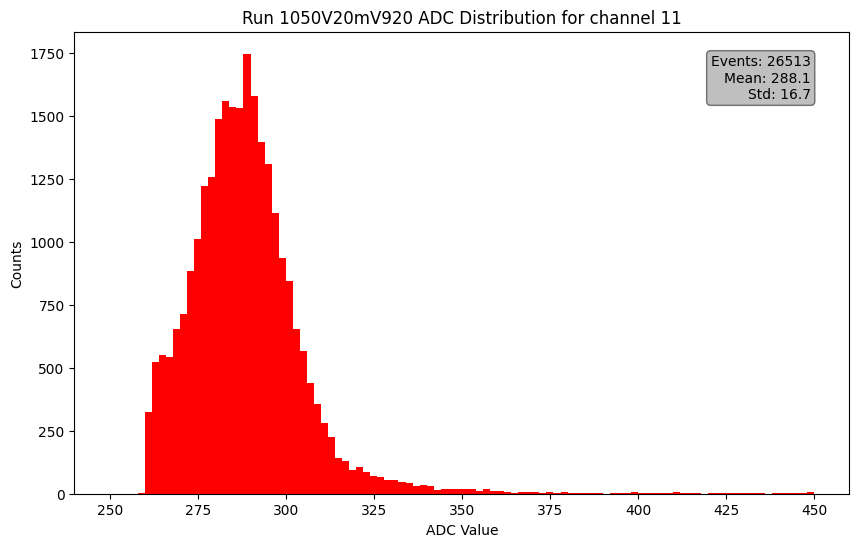

In [5]:
# fill histogram
plt.figure(figsize=(10, 6))
plt.hist(data['adcs'], bins=100, range=(250, 450), color='red')
# show number of events, mean and standard deviation, for values between 250 and 450
mask_adc = ((data['adcs'] >= 250) & (data['adcs'] <= 450))
# show number of events, mean and standard deviation for values between 250 and 450 in a box in upper right of plot
n_evt = np.sum(mask_adc)
mean = np.mean(data['adcs'][mask_adc])
std = np.std(data['adcs'][mask_adc])
textstr = '\n'.join((
    f'Events: {n_evt}',
    f'Mean: {mean:.1f}',
    f'Std: {std:.1f}'))
props = dict(boxstyle='round', facecolor='grey', alpha=0.5)
plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=props)

# overlay a vertical line for the threshold
#plt.axvline(threshold, color='black', linestyle='--', label='Threshold')
#plt.legend()
#plt.yscale('log')
plt.xlabel('ADC Value')
plt.ylabel('Counts')
plt.title(f'Run {run_name} ADC Distribution for channel {data['channel']}')
plt.savefig(f'I:/fd2_analyses/adc_distribution_run{run_name}_chan{data['channel']:02d}.png')
plt.show()

In [34]:
run_name='1200V40mV920'
channel = 11
data = get_data(run_name=run_name, channel=channel)

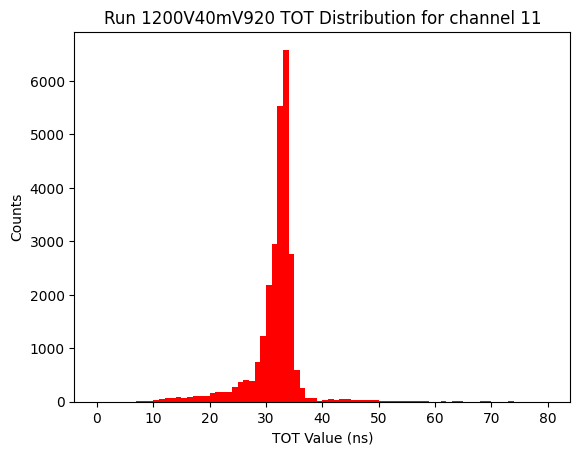

In [7]:
# plot tot distribution for the first active channel
plt.hist(data['tots'], bins=80, range=(0, 80), color='red')

plt.xlabel('TOT Value (ns)')
plt.ylabel('Counts')
plt.title(f'Run {run_name} TOT Distribution for channel {channel}')
plt.savefig(f'I:/fd2_analyses/tot_distribution_run{run_name}_chan{channel:02d}.png')
plt.show()

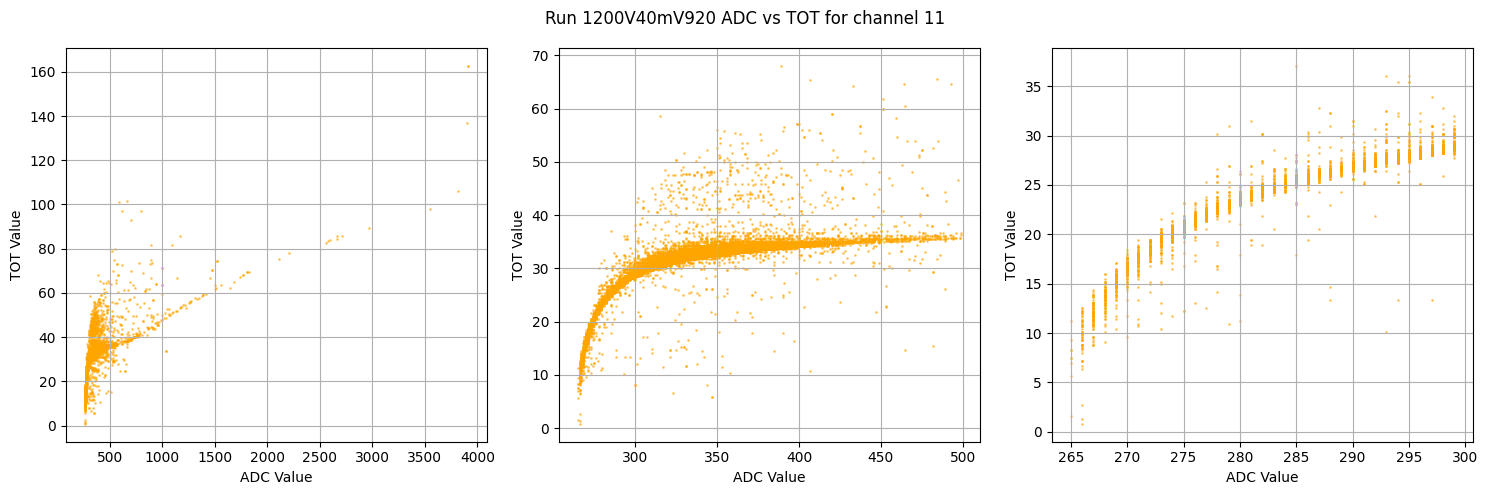

In [35]:
# show a scatter plot of ADC vs TOT. Show 3 subplots. the second one showing only ADC < 500, third ADC < 300
# optionally apply a requirement to select events consistent with an LED flashing
apply_mask = False

if apply_mask:
    mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))  # (within 20 ns of expected time)
else:
    mask_led = data['pmt_time_modulus_zeroeds'] != None  # all events

fig, ax = plt.subplots(1,3,figsize=(15, 5))

ax[0].scatter(data['adcs'][mask_led], data['tots'][mask_led], s=1, alpha=0.5, color='orange')
ax[0].set_xlabel('ADC Value')
ax[0].set_ylabel('TOT Value')
ax[0].grid(True)

mask_adc = data['adcs'][mask_led] < 500.
ax[1].scatter(data['adcs'][mask_led][mask_adc], data['tots'][mask_led][mask_adc], s=1, alpha=0.5, color='orange')
ax[1].set_xlabel('ADC Value')
ax[1].set_ylabel('TOT Value')
ax[1].grid(True)

mask_adc = data['adcs'][mask_led] < 300.
ax[2].scatter(data['adcs'][mask_led][mask_adc], data['tots'][mask_led][mask_adc], s=1, alpha=0.5, color='orange')
ax[2].set_xlabel('ADC Value')
ax[2].set_ylabel('TOT Value')
ax[2].grid(True)

if apply_mask:
    plt.suptitle(f'Run {run_name} LED ADC vs TOT for channel {channel}')
    extra='_LED'
else:
    plt.suptitle(f'Run {run_name} ADC vs TOT for channel {channel}')
    extra=''
plt.tight_layout()
plt.savefig(f'I:/fd2_analyses/adc_vs_tot_run{run_name}_chan{channel:02d}{extra}.png')
plt.show()

In [9]:
run_name='1150V40mV898'
channel = 11
data = get_data(run_name=run_name, channel=channel)

Time Range: 0 to 20.00


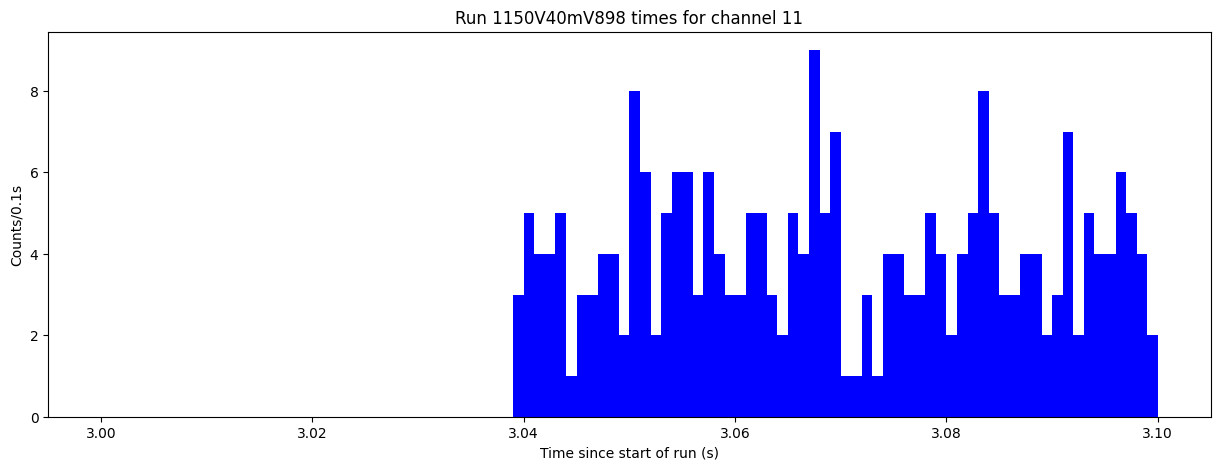

In [10]:
# plot the pmt time distribution with respect to the first signal - to see how

time_min = np.min(data['pmt_times'])*4E-9
time_max = min(time_min+20,np.max(data['pmt_times'])*4E-9)
print(f"Time Range: 0 to {time_max-time_min:0.2f}")

# make the plot wider
plt.figure(figsize=(15, 5))
#plt.hist(data['pmt_times']*4E-9-time_min, bins=np.arange(0.,time_max-time_min,0.1), color='blue')
plt.hist(data['pmt_times']*4E-9-time_min, bins=np.arange(3.0,3.1,0.001), color='blue')
#plt.yscale('log')
plt.xlabel('Time since start of run (s)')
plt.ylabel('Counts/0.1s')
plt.title(f'Run {run_name} times for channel {channel}')
#plt.grid(True)
plt.savefig(f'I:/fd2_analyses/time_distribution_run{run_name}_chan{channel:02d}.png')
plt.show()

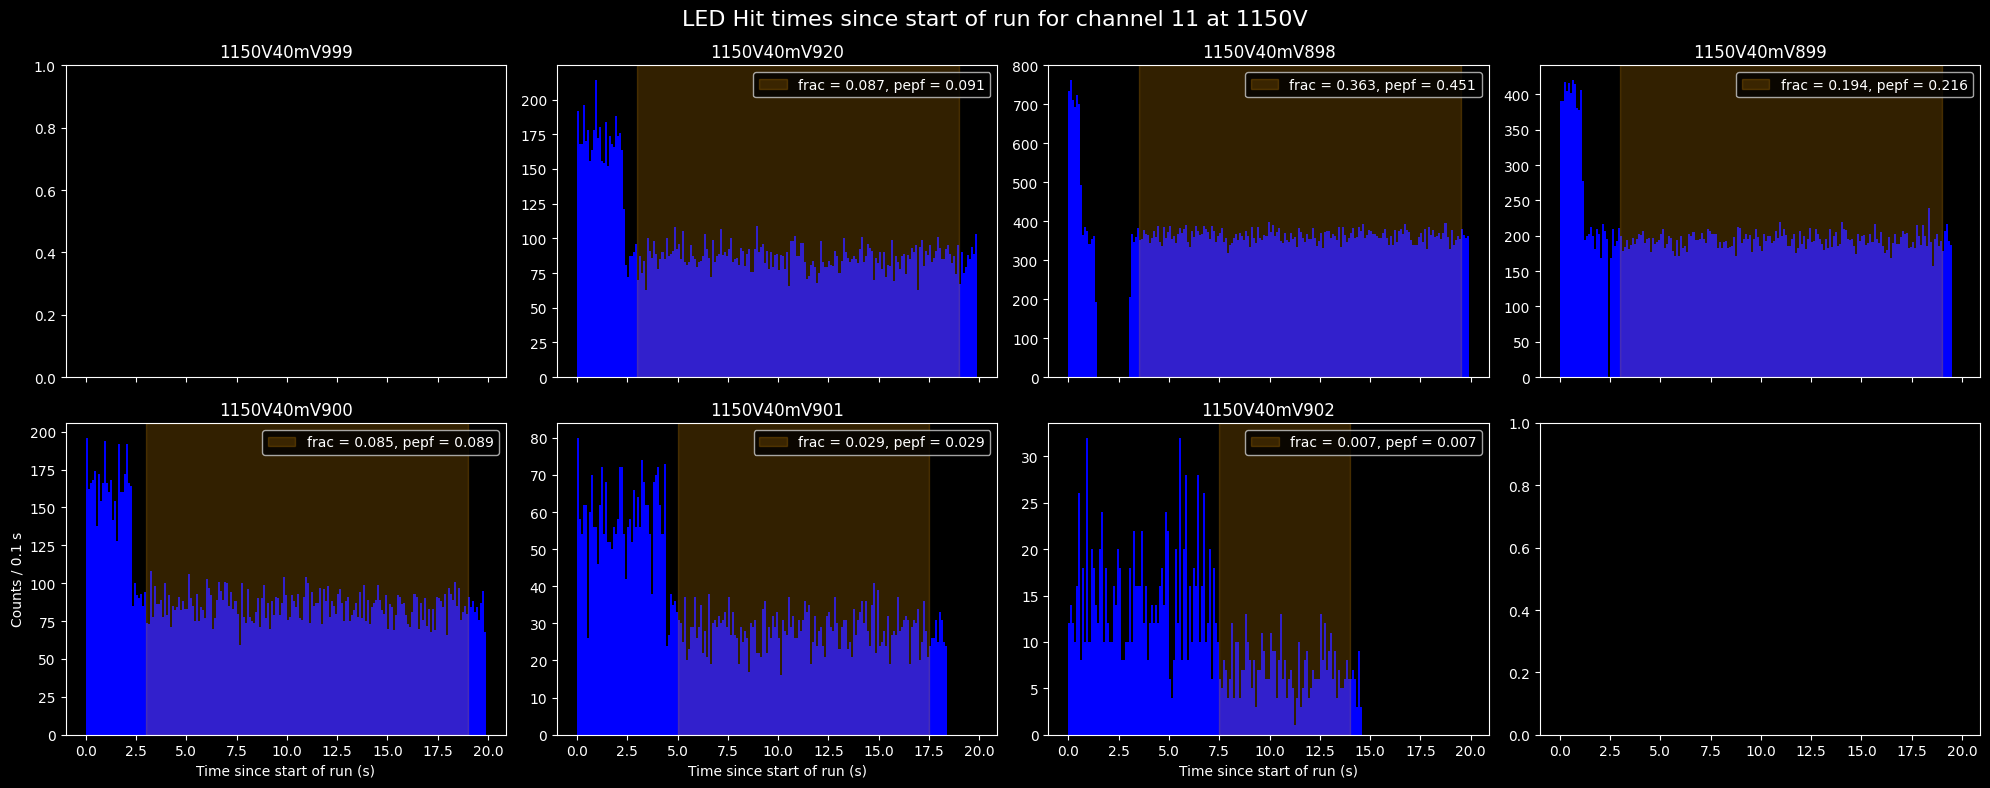

In [43]:
# show the time since start for all runs at 1150V. There are 7 runs, so do 2 rows and 4 columns of subplots, with the last one empty.
# All between 0 and 20 seconds, sharex = True.

# optionally apply a requirement to select events consistent with an LED flashing
apply_mask = True
# range to assess observed rate -> pepf
pre_run = False

channel = 11
d_time_max = 20.
time_bin = 0.1
run_period_1150V = {920:[3,19],898:[3.5,19.5],899:[3,19],900:[3,19],901:[5.0,17.5], 902:[7.5,14]}
pre_run_period_1150V = {920:[0,2],898:[0,0.55],899:[0,1],900:[0,2],901:[0,4], 902:[0,6.5]}

fig, ax = plt.subplots(2,4,figsize=(20, 8), sharex=True)

pepfs = {}

i_plot = 0
for run_name in run_names:
    if '1150V' in run_name:
        axis = ax[i_plot//4, i_plot%4]
        d = get_data(run_name=run_name, channel=channel)
        if not apply_mask or 'V999' not in run_name:
            if apply_mask:
                mask_led = ((d['pmt_time_modulus_zeroeds'] > -5) & (d['pmt_time_modulus_zeroeds'] < 5))  # (within 20 ns of expected time)
            else:
                mask_led = d['pmt_times'] != 0.1  # all events
            time_min = np.min(d['pmt_times'][mask_led])*4E-9
            axis.hist(d['pmt_times'][mask_led]*4E-9-time_min,bins=np.arange(0.,d_time_max,time_bin), color='blue')
            if i_plot in [0,4]:
                axis.set_ylabel(f'Counts / {time_bin:0.1f} s')
            if i_plot > 3:
                axis.set_xlabel('Time since start of run (s)')

        if apply_mask and 'V999' not in run_name:
            mask_led = ((d['pmt_time_modulus_zeroeds'] > -5) & (d['pmt_time_modulus_zeroeds'] < 5))  # (within 20 ns of expected time)
            # show vertical lines that show the period with constant rate
            attenuation = int(run_name[-3:])
            if attenuation in run_period_1150V:
                period_range = run_period_1150V[attenuation]
                if pre_run:
                    period_range = pre_run_period_1150V[attenuation]
                period_length = period_range[1] - period_range[0]
                flashes = period_length/period*1E9
                all_led_times = d['pmt_times'][mask_led]*4E-9-time_min
                mask_period = ((all_led_times >= period_range[0]) & (all_led_times <= period_range[1]))
                pulses = np.sum(mask_period)
                fraction = pulses/flashes
                pepf = -np.log(1.-fraction)
                pepfs[run_name] = pepf
                label = f'frac = {fraction:0.3f}, pepf = {pepf:0.3f}'
                if pre_run:
                    label = f'frac = {fraction:0.3f}*, pepf = {pepf:0.3f}*'
                axis.axvspan(period_range[0], period_range[1], color='orange', alpha=0.2, label=label)
                axis.legend()
        axis.set_title(f'{run_name}')
        i_plot += 1

extra = ''
if apply_mask:
    extra = ('LED')
    if pre_run:
        extra = f'{extra}_pre'
plt.suptitle(f'{extra} Hit times since start of run for channel {channel} at 1150V', fontsize=16)
plt.tight_layout()
plt.savefig(f'I:/fd2_analyses/hit_times_1150V_chan{channel:02d}{extra}.png')
plt.show()

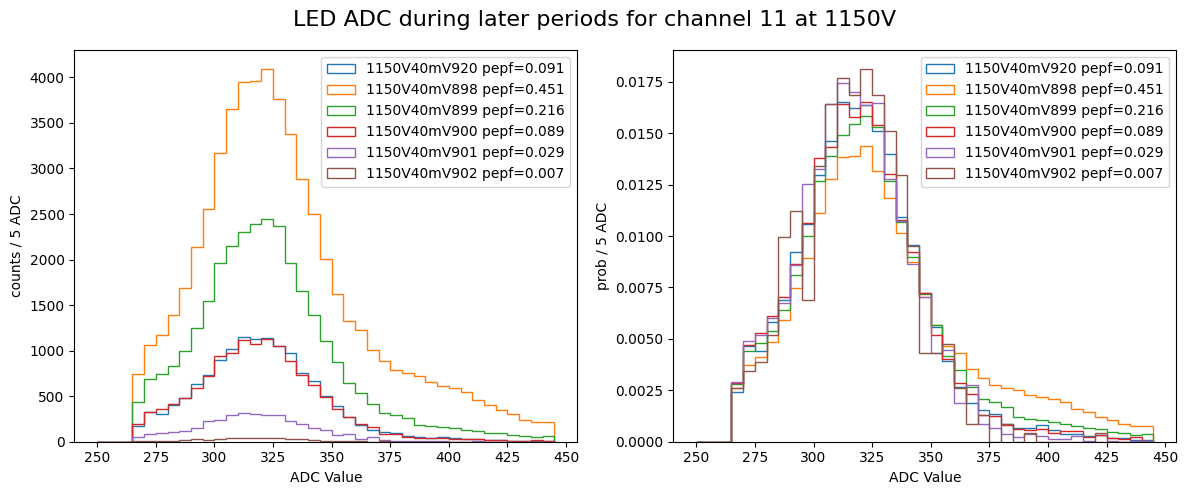

In [45]:
# Compare the ADC distributions for the different runs at 1150V (no including the pre-run period), to show how the shape changes as the pepf increases.
# Normalize them, to compare shapes directly. Show in single plot, with unfilled histograms

fig, ax = plt.subplots(1,2,figsize=(12, 5))

for run_name in pepfs:
    pepf = pepfs[run_name]
    data = get_data(run_name=run_name, channel=channel)
    attenuation = int(run_name[-3:])
    period_range = run_period_1150V[attenuation]
    mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))  # (within 20 ns of expected time)
    time_min = np.min(data['pmt_times'][mask_led])*4E-9
    all_led_times = data['pmt_times'][mask_led]*4E-9-time_min
    mask_period = ((all_led_times >= period_range[0]) & (all_led_times <= period_range[1]))
    ax[0].hist(data['adcs'][mask_led][mask_period], bins=np.arange(250,450,5), density=False, histtype='step', label=f'{run_name} pepf={pepf:0.3f}')
    ax[1].hist(data['adcs'][mask_led][mask_period], bins=np.arange(250,450,5), density=True, histtype='step', label=f'{run_name} pepf={pepf:0.3f}')

ax[0].legend()
ax[1].legend()
ax[0].set_xlabel('ADC Value')
ax[1].set_xlabel('ADC Value')
ax[0].set_ylabel('counts / 5 ADC')
ax[1].set_ylabel('prob / 5 ADC')

plt.suptitle(f'LED ADC during later periods for channel {channel} at 1150V', fontsize=16)
plt.tight_layout()
plt.savefig(f'I:/fd2_analyses/adc_1150V_chan{channel:02d}_later.png')
plt.show()



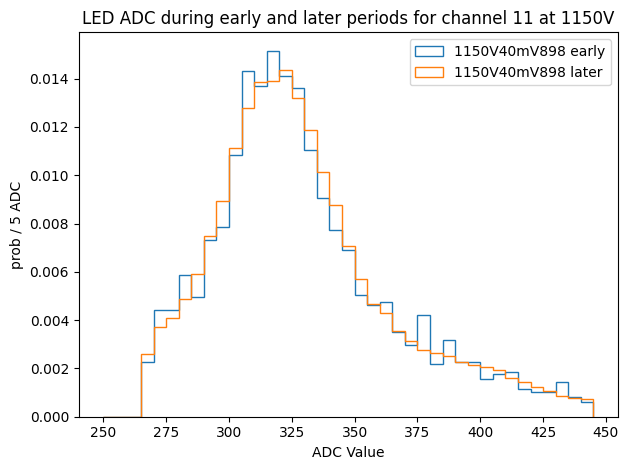

In [46]:
# Compare the ADC distribution for attenuation 898 for the pre-run period (0-0.55 s) and the later period (3.5-19.5 s),
# to check if the shape changes or not... It does not - so the full run data can be used, the anomalous rates due to coarse time mangling
run_name = '1150V40mV898'
data = get_data(run_name=run_name, channel=channel)

mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))  # (within 20 ns of expected time)
time_min = np.min(data['pmt_times'][mask_led])*4E-9
all_led_times = data['pmt_times'][mask_led]*4E-9-time_min
mask_period_pre = ((all_led_times >= 0) & (all_led_times <= 0.55))
mask_period_later = ((all_led_times >= 3.5) & (all_led_times <= 19.5))

plt.hist(data['adcs'][mask_led][mask_period_pre], bins=np.arange(250,450,5), density=True, histtype='step', label=f'{run_name} early')
plt.hist(data['adcs'][mask_led][mask_period_later], bins=np.arange(250,450,5), density=True, histtype='step', label=f'{run_name} later')
plt.legend()
plt.xlabel('ADC Value')
plt.ylabel('prob / 5 ADC')
plt.title(f'LED ADC during early and later periods for channel {channel} at 1150V')
plt.tight_layout()
plt.savefig(f'I:/fd2_analyses/adc_1150V_chan{channel:02d}_early_later.png')
plt.show()


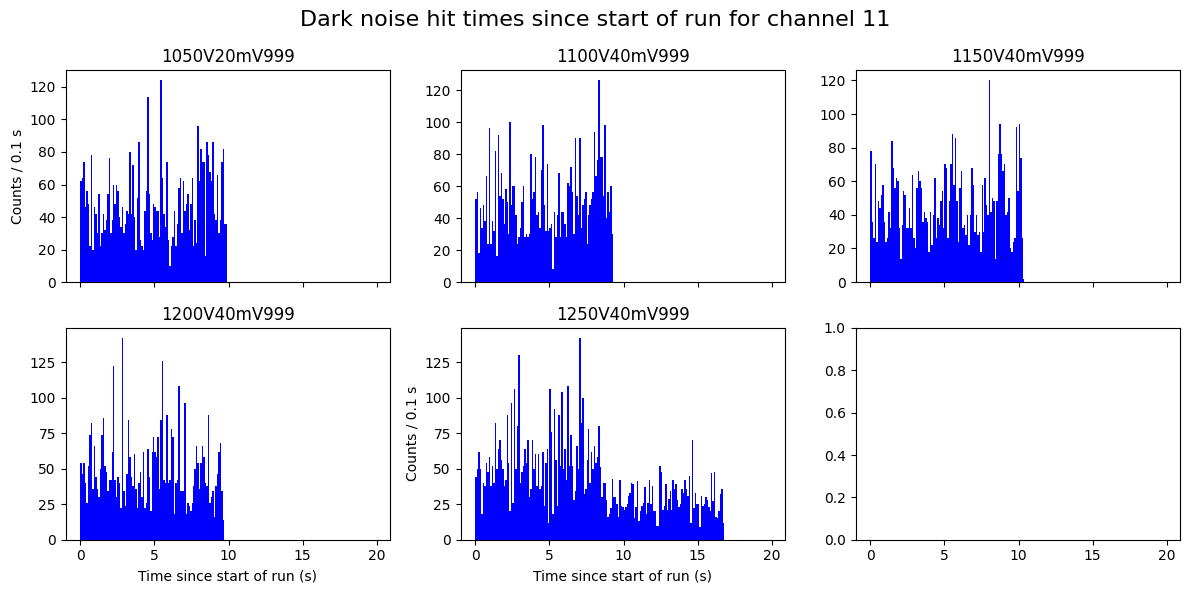

In [14]:
# show the time since start for all runs with no LED. There are 5 runs, so do 2 rows and 3 columns of subplots, with the last one empty.
# All between 0 and 20 seconds, sharex = True.

channel = 11
d_time_max = 20.
time_bin = 0.1

fig, ax = plt.subplots(2,3,figsize=(12, 6), sharex=True)

pepfs = {}

i_plot = 0
for run_name in run_names:
    if 'V999' in run_name:
        axis = ax[i_plot//3, i_plot%3]
        d = get_data(run_name=run_name, channel=channel)
        time_min = np.min(d['pmt_times'])*4E-9
        axis.hist(d['pmt_times']*4E-9-time_min,bins=np.arange(0.,d_time_max,time_bin), color='blue')
        if i_plot in [0,4]:
            axis.set_ylabel(f'Counts / {time_bin:0.1f} s')
        if i_plot > 2:
            axis.set_xlabel('Time since start of run (s)')

        axis.set_title(f'{run_name}')
        i_plot += 1

plt.suptitle(f'Dark noise hit times since start of run for channel {channel}', fontsize=16)
plt.tight_layout()
plt.savefig(f'I:/fd2_analyses/dark_hit_times_chan{channel:02d}.png')
plt.show()

In [15]:
run_name='1150V40mV999'
channel = 11
data = get_data(run_name=run_name, channel=channel)

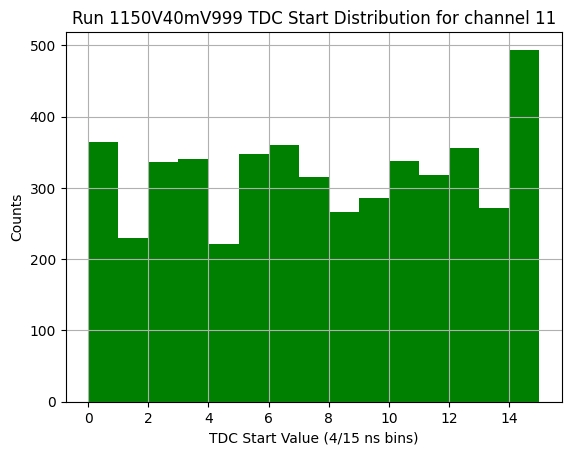

In [16]:
# Look at the distribution of tdc_start values for dark noise events. Should be uniform

plt.hist(data['tdc_starts'], bins=np.arange(0,16,1), color='green')
plt.xlabel('TDC Start Value (4/15 ns bins)')
plt.ylabel('Counts')
plt.title(f'Run {run_name} TDC Start Distribution for channel {channel}')
plt.grid(True)
plt.savefig(f'I:/fd2_analyses/tdc_start_distribution_run{run_name}_chan{channel:02d}.png')
plt.show()

In [47]:
run_name='1150V40mV920'
channel = 11
data = get_data(run_name=run_name, channel=channel)

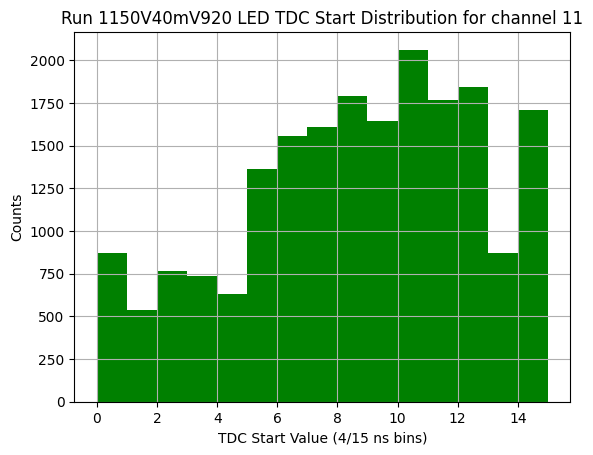

In [48]:
# look at distribution for LED pulses

mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))  # (within 20 ns of expected time)

plt.hist(data['tdc_starts'][mask_led], bins=np.arange(0,16,1), color='green')
plt.xlabel('TDC Start Value (4/15 ns bins)')
plt.ylabel('Counts')
plt.title(f'Run {run_name} LED TDC Start Distribution for channel {channel}')
plt.grid(True)
plt.savefig(f'I:/fd2_analyses/tdc_start_distribution_run{run_name}_chan{channel:02d}LED.png')
plt.show()

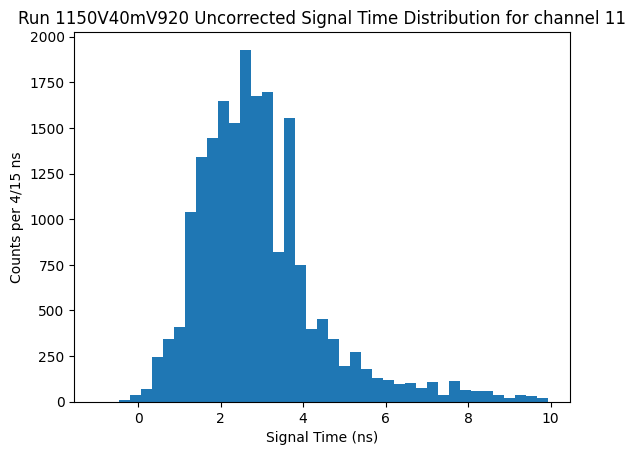

In [53]:
# Look at the signal times for the events near the expected LED flash time
plt.hist(data['signal_times'][mask_led],bins=np.arange(-1.,10.,4./15))
plt.xlabel('Signal Time (ns)')
plt.ylabel('Counts per 4/15 ns')
plt.title(f'Run {run_name} Uncorrected Signal Time Distribution for channel {channel}')
plt.savefig(f'I:/fd2_analyses/signal_time_distribution_run{run_name}_chan{channel:02d}LED.png')
plt.show()

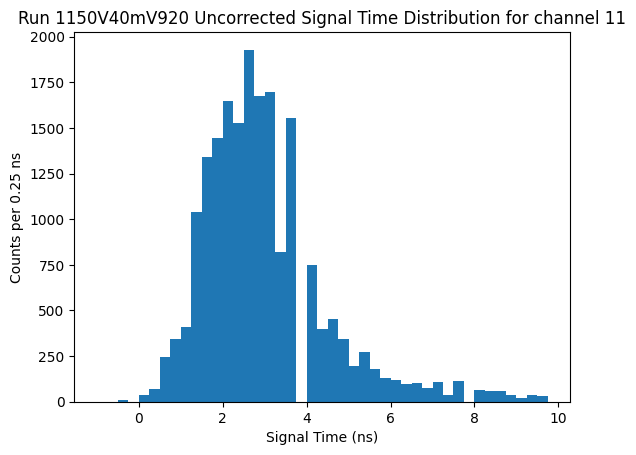

In [55]:
# Look at the signal times for the events near the expected LED flash time
#plt.hist(data['signal_times'][mask_led],bins=np.arange(-4.,20.,4./15))
plt.hist(data['signal_times'][mask_led],bins=np.arange(-1.,10.,0.25))
plt.xlabel('Signal Time (ns)')
plt.ylabel('Counts per 0.25 ns')
plt.title(f'Run {run_name} Uncorrected Signal Time Distribution for channel {channel}')
plt.savefig(f'I:/fd2_analyses/signal_time_distribution_run{run_name}_chan{channel:02d}LED_bin25.png')
plt.show()

In [20]:
run_name='1200V40mV920'
channel = 11
data = get_data(run_name=run_name, channel=channel)

C:\Users\karlen\AppData\Local\Temp\ipykernel_23104\1656569514.py:57: RuntimeWarning: divide by zero encountered in divide
  popt, pcov = curve_fit(lambda x, A, mu, sigma: A * np.exp(-(x - mu)**2 / (2 * sigma**2)), bin_centers, hist, p0=p0)
C:\Users\karlen\AppData\Local\Temp\ipykernel_23104\1656569514.py:57: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(lambda x, A, mu, sigma: A * np.exp(-(x - mu)**2 / (2 * sigma**2)), bin_centers, hist, p0=p0)
C:\Users\karlen\AppData\Local\Temp\ipykernel_23104\1656569514.py:63: RuntimeWarning: invalid value encountered in divide
  y_fit = popt[0] * np.exp(-(x_fit - popt[1])**2 / (2 * popt[2]**2))


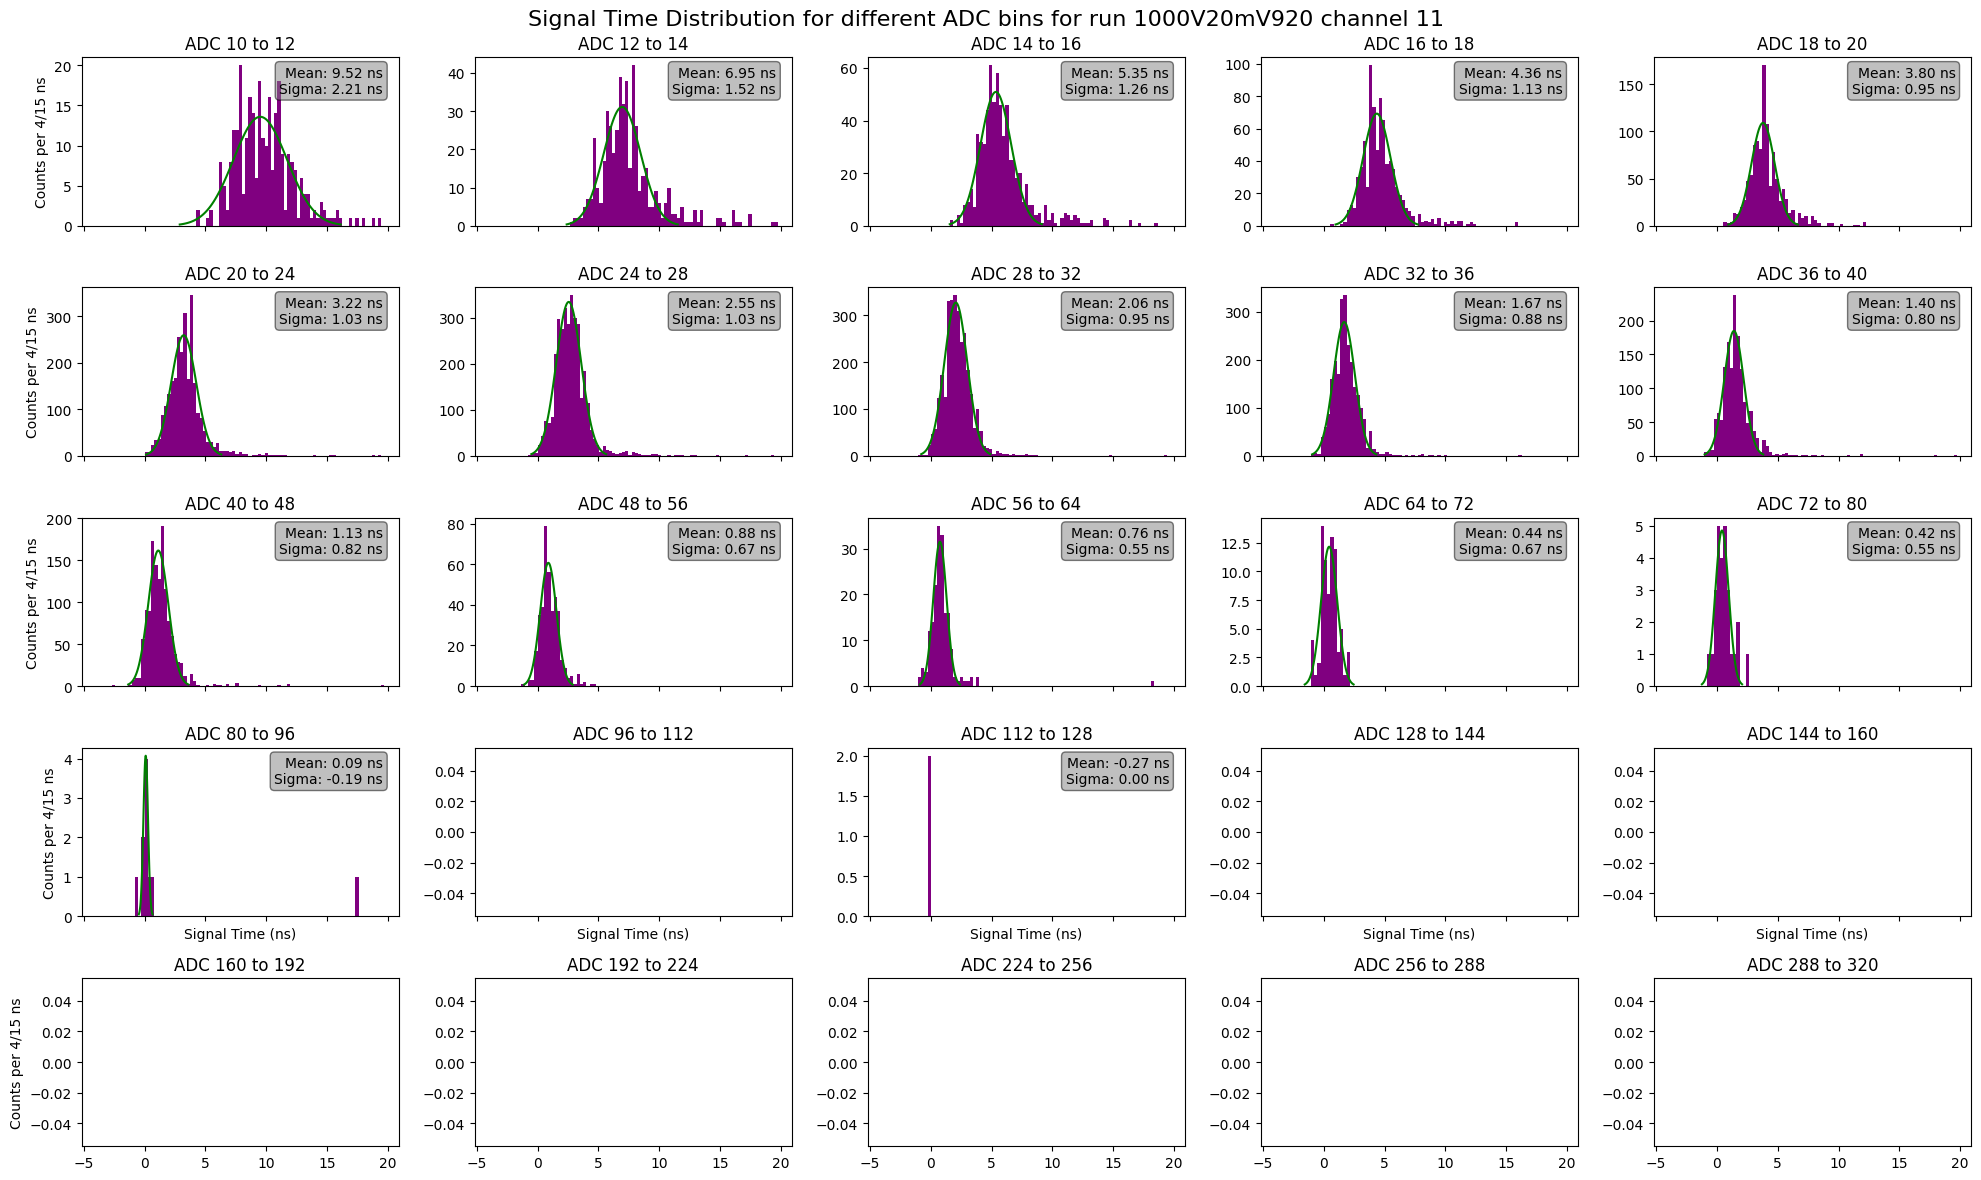

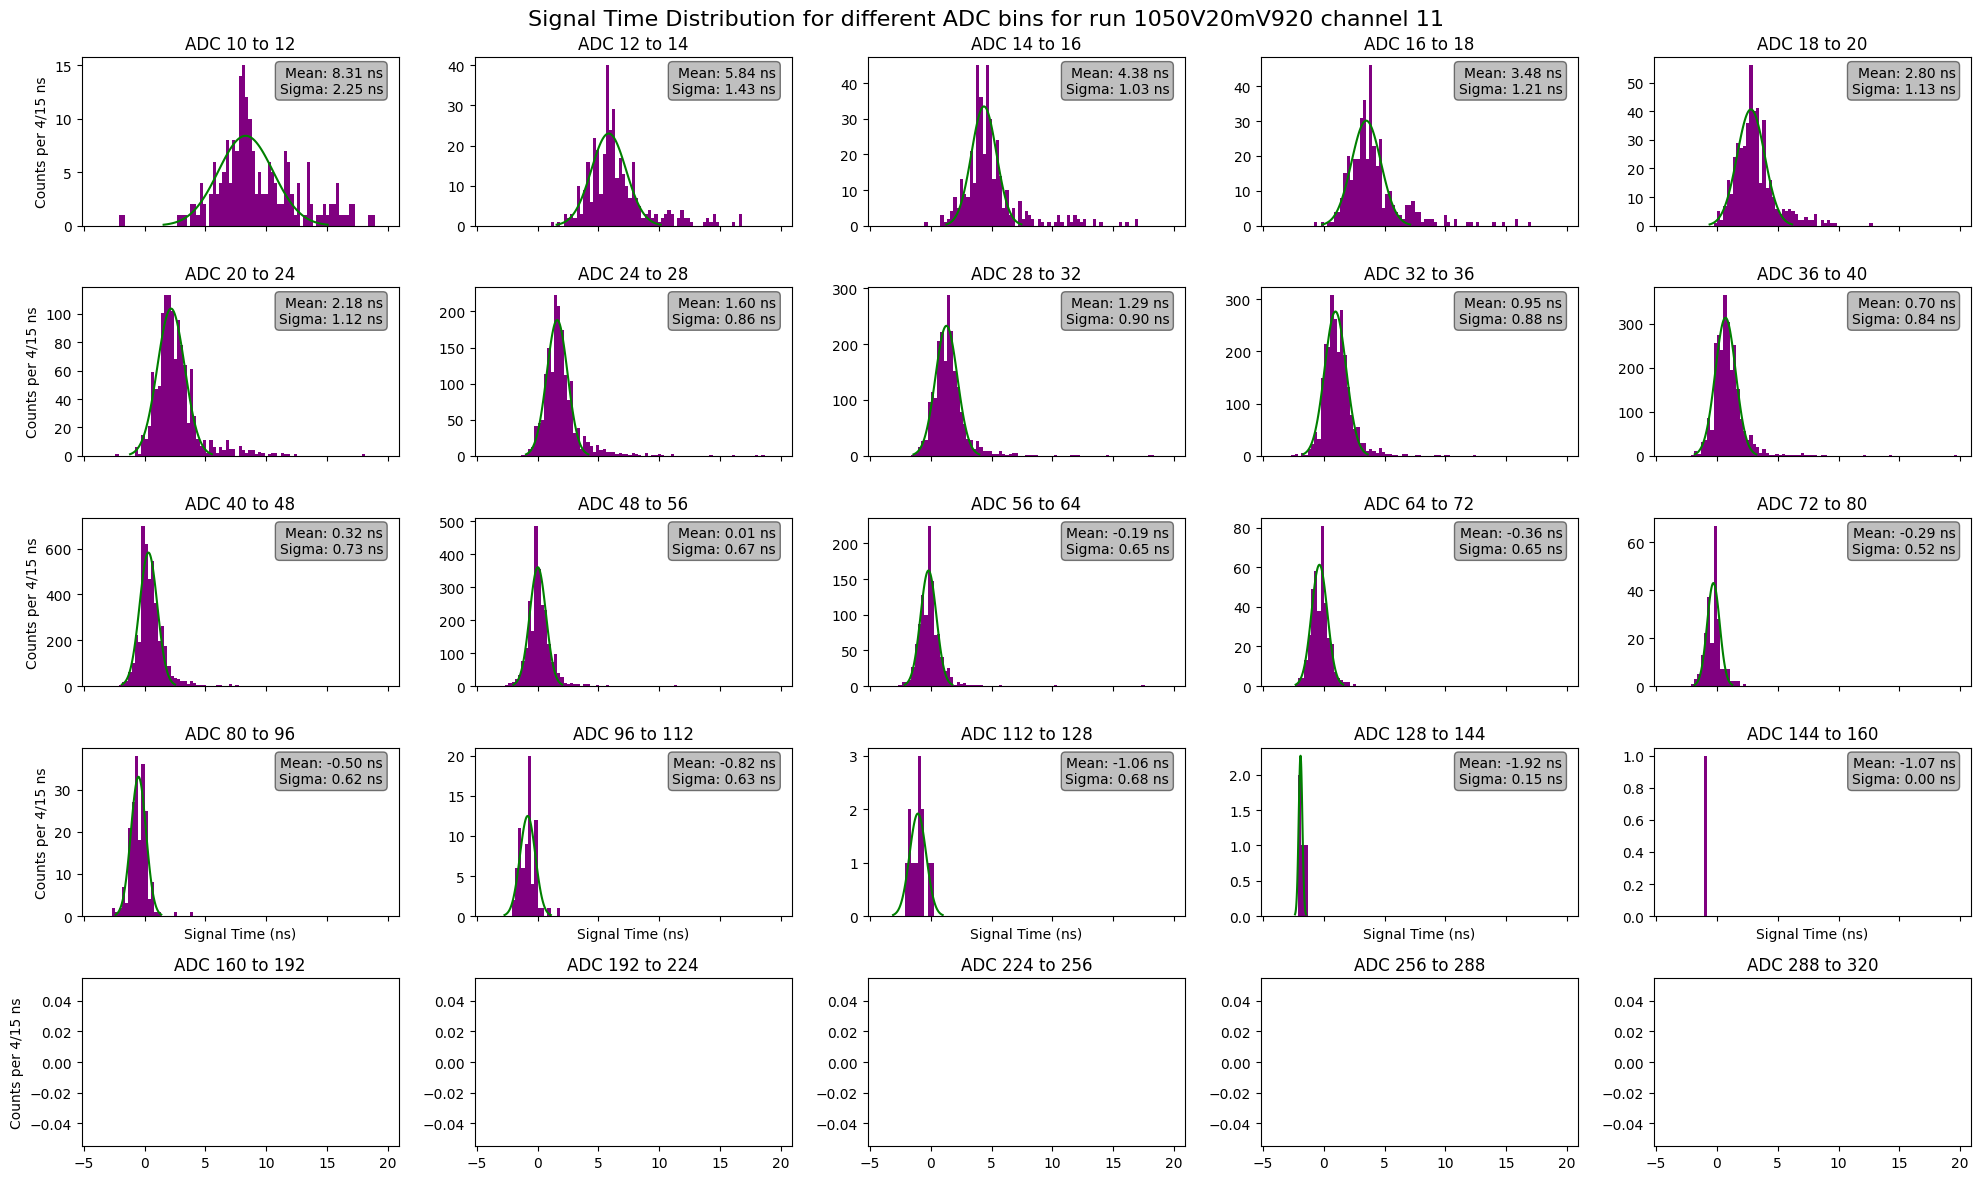

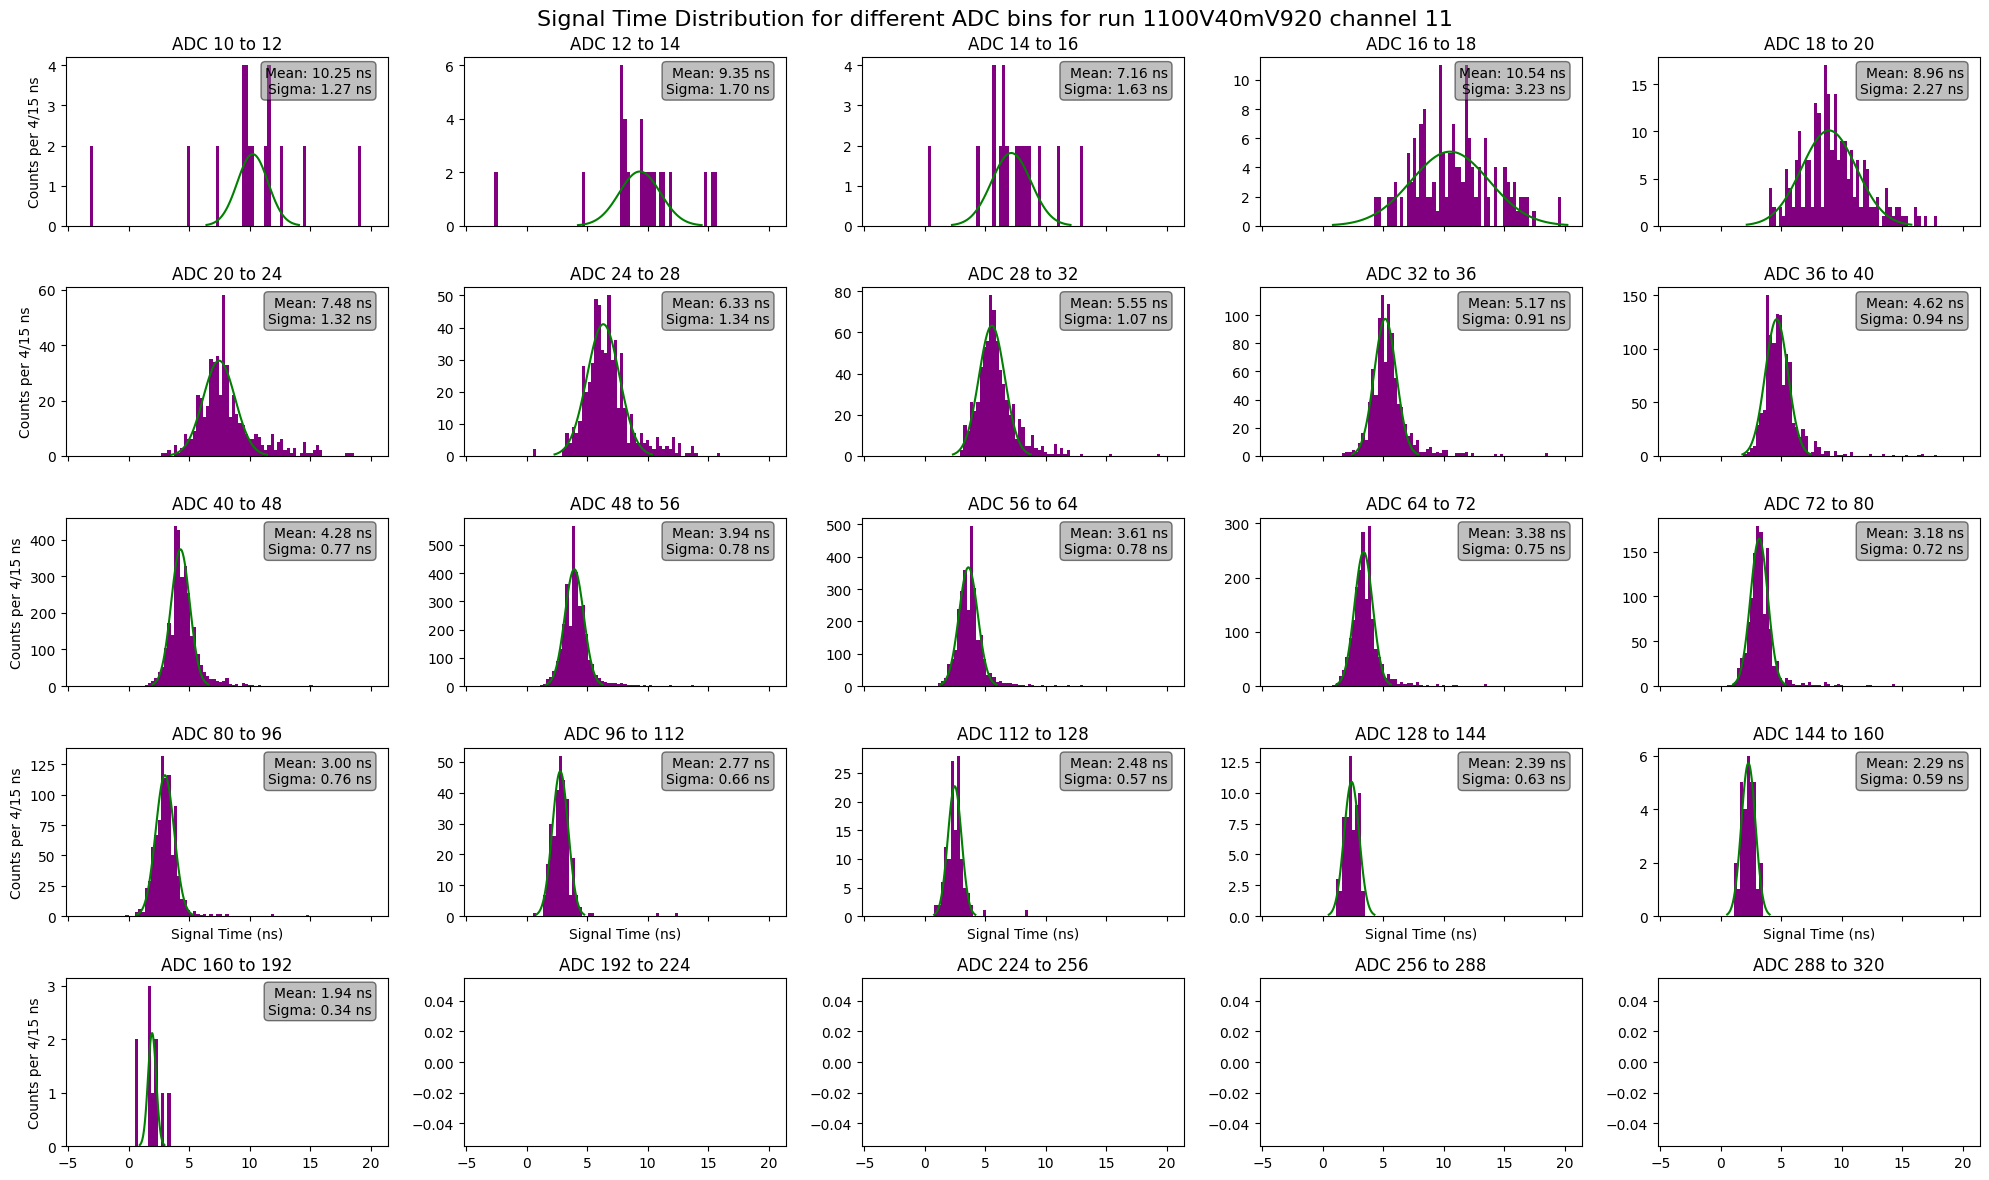

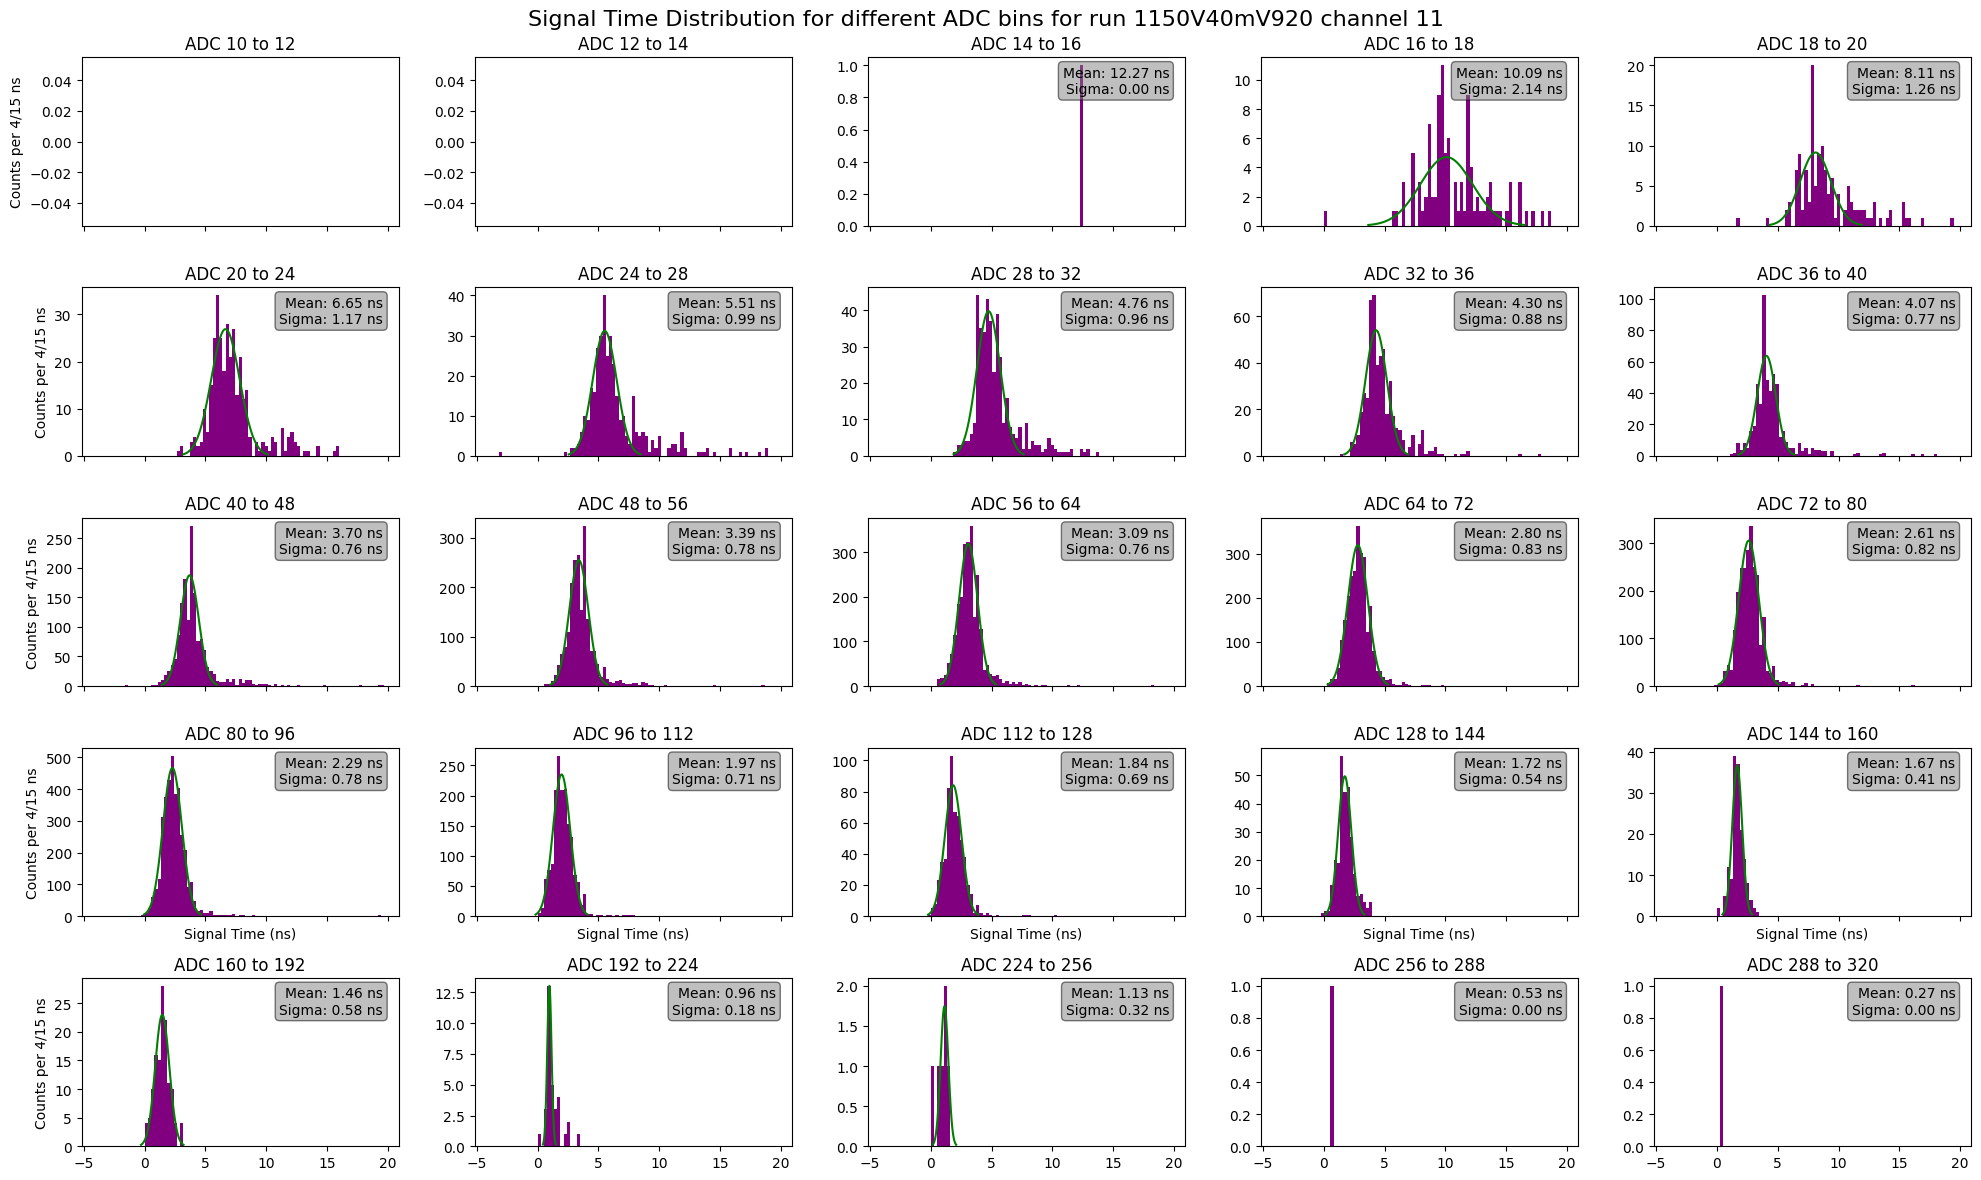

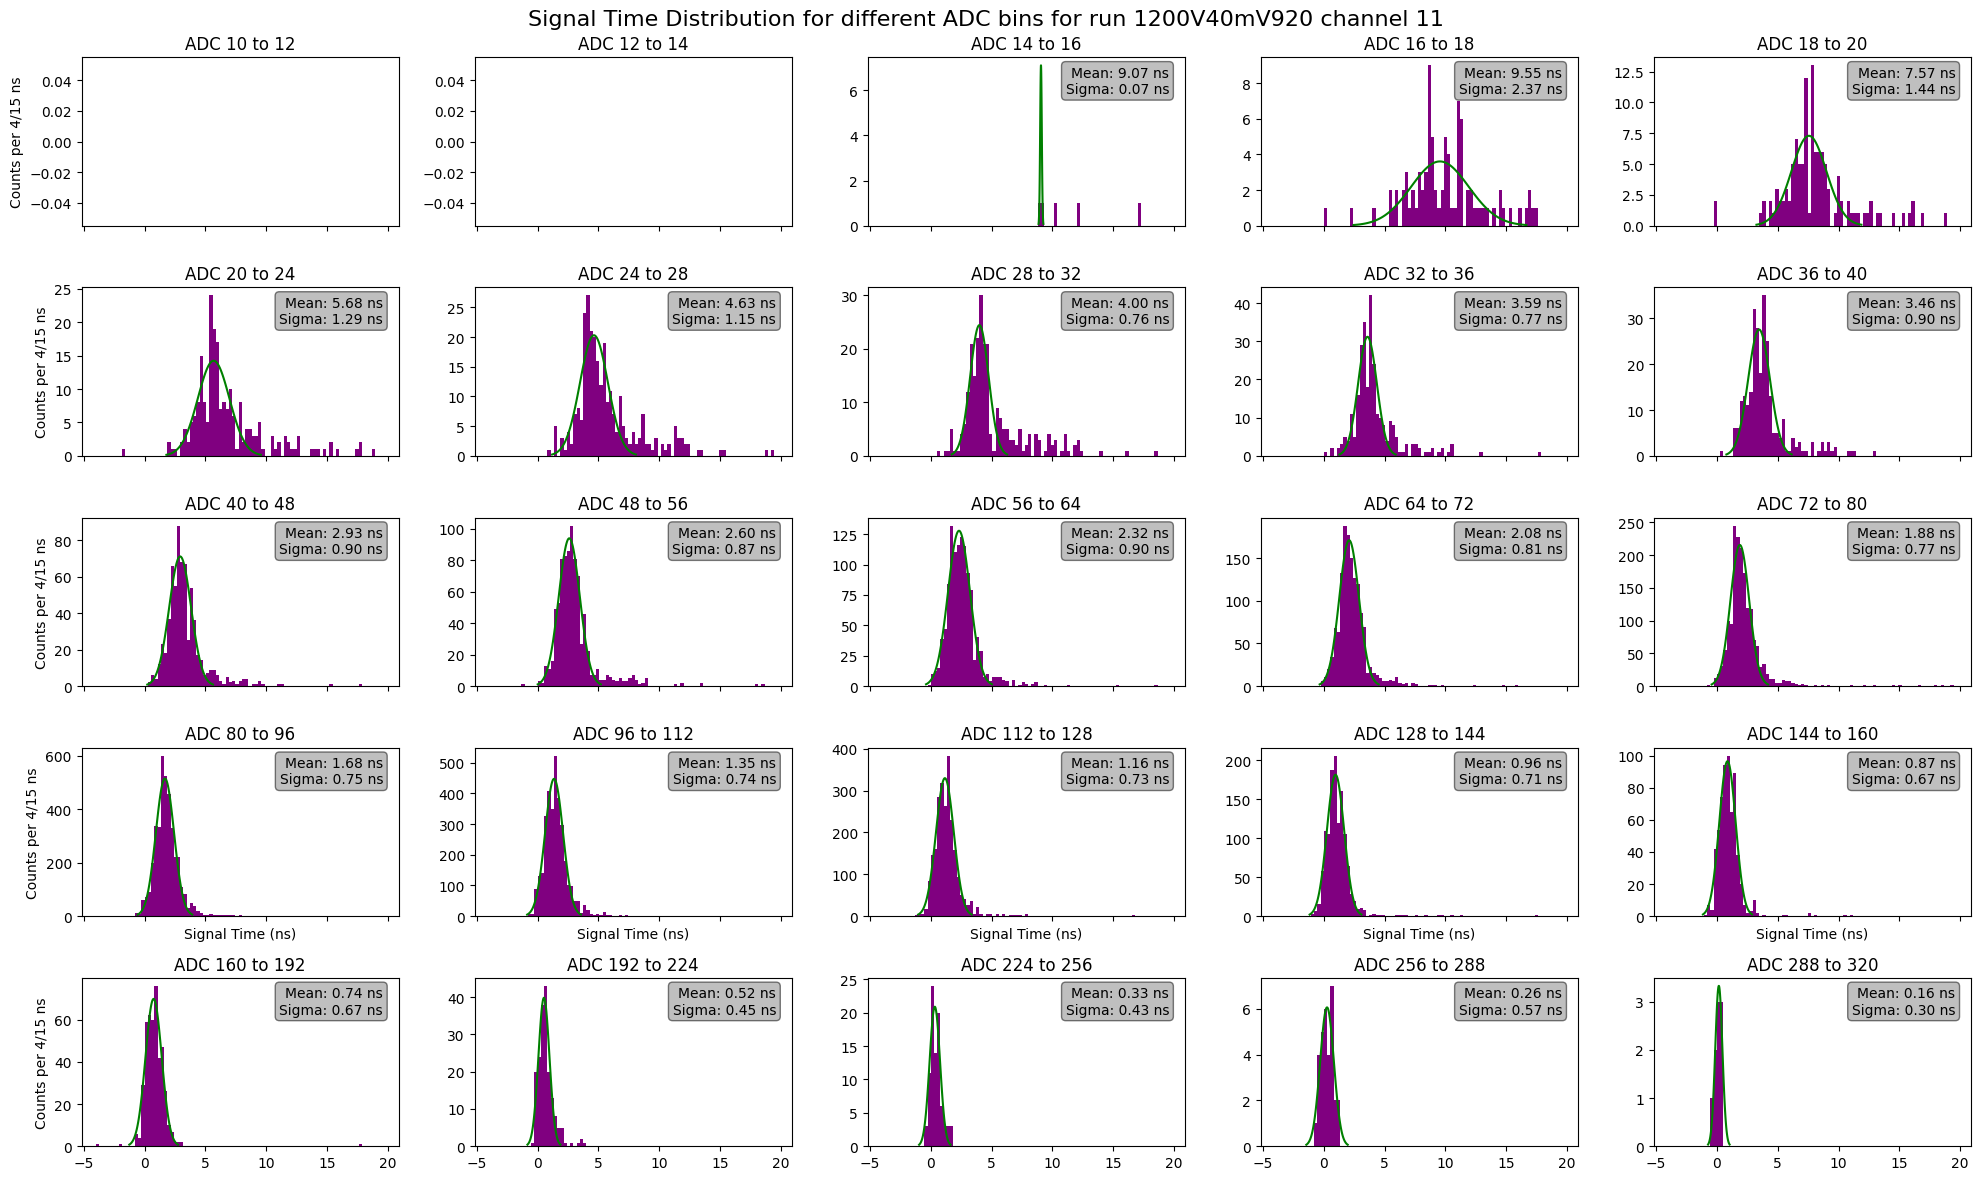

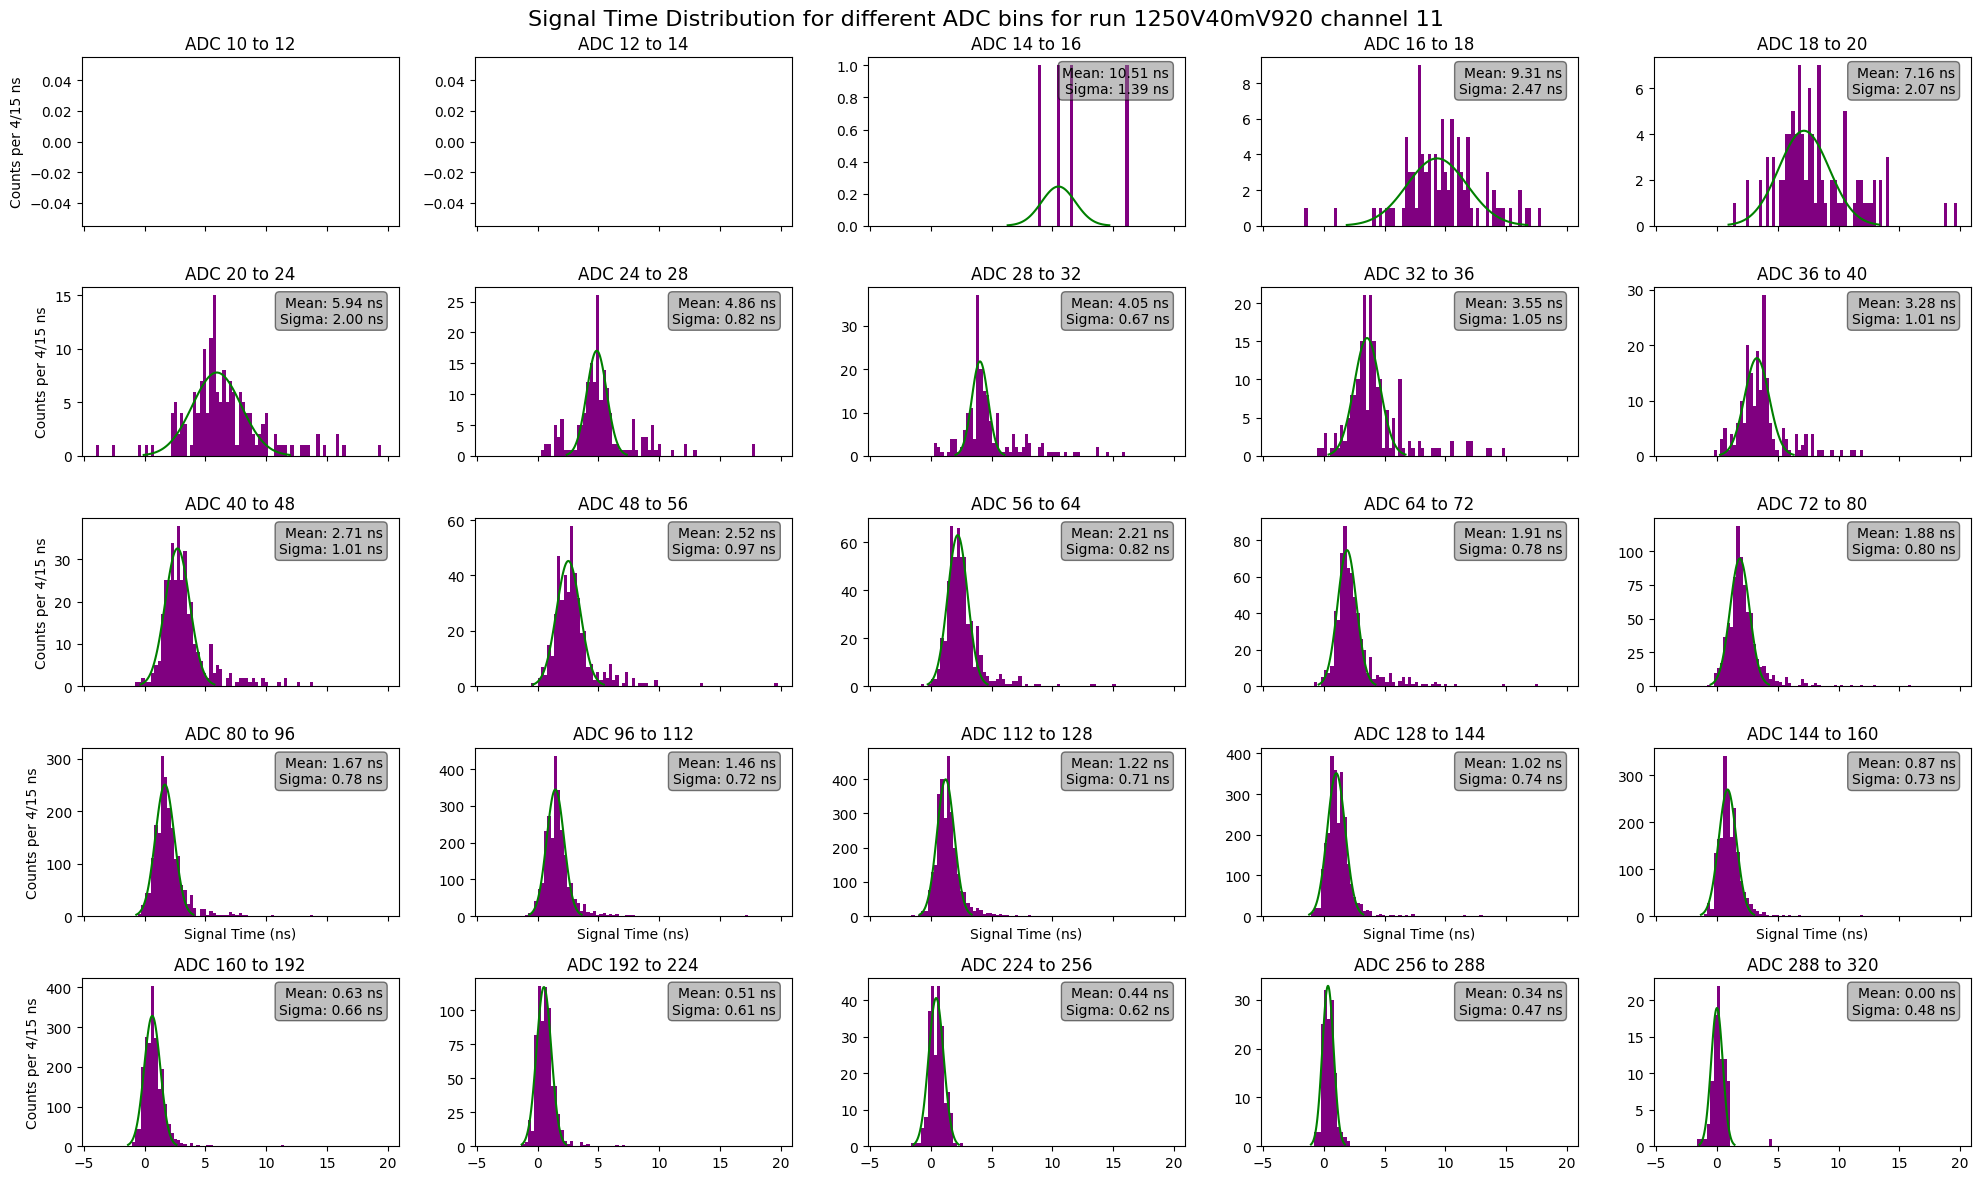

In [21]:
# The mean and standard deviation of the signal times will depend on the amplitude of the pulse.
# Look at the signal time distribution as a function of ADC value, by considering bins of ADC values.
# For each bin, plot the distribution of signal times, and fit to a Gaussian to extract the mean and standard deviation
# of the signal time for that ADC bin.

time_walk_correction_funcs = {}
time_walk_correction_ranges = {}
time_walk_correction_means_sel = {}
time_walk_correction_stds_sel = {}
time_walk_correction_bin_centers_sel = {}

adc_offset = 250
adc_bin_min = 10

# Use more bins at low ADC where the correction is more substantial
bin_width = 2
adc_bin_edges = [adc_bin_min]
for row in range(5):
    for col in range(5):
        adc_bin_edges.append(adc_bin_edges[-1] + bin_width)
    if row < 4:
        bin_width *= 2

for run_name in run_names:
    if 'V920' in run_name:
        channel = 11
        data = get_data(run_name=run_name, channel=channel)

        mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))

        n_signal_times = []
        mean_signal_times = []
        std_signal_times = []

        # Make subplots in 4x5 grid, in each plot show the signal time distribution for a different ADC bin
        fig, ax = plt.subplots(5, 5, figsize=(20, 12), sharex=True)

        for i in range(len(adc_bin_edges)-1):
            axis = ax[i//5, i%5]
            bin = [adc_bin_edges[i]+adc_offset, adc_bin_edges[i+1]+adc_offset]
            mask_adc_bin = ((data['adcs'] >= bin[0]) & (data['adcs'] < bin[1]) & mask_led)
            signal_times_adc_bin = data['signal_times'][mask_adc_bin]
            axis.hist(signal_times_adc_bin, bins=np.arange(-4.,20.,4./15), color='purple')
            axis.set_title(f'ADC {bin[0]-adc_offset} to {bin[1]-adc_offset}')

            if i%5 == 0:
                axis.set_ylabel('Counts per 4/15 ns')
            if i//5 == 3:
                axis.set_xlabel('Signal Time (ns)')
            # Fit to a Gaussian
            if len(signal_times_adc_bin) > 0:
                hist, bin_edges = np.histogram(signal_times_adc_bin, bins=np.arange(-4.,20.,4./15))
                bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
                # Initial guess for fit parameters: amplitude, mean, stddev
                p0 = [np.max(hist), np.mean(signal_times_adc_bin), np.std(signal_times_adc_bin)]
                try:
                    popt, pcov = curve_fit(lambda x, A, mu, sigma: A * np.exp(-(x - mu)**2 / (2 * sigma**2)), bin_centers, hist, p0=p0)
                    n_signal_times.append(hist.sum())
                    mean_signal_times.append(popt[1])
                    std_signal_times.append(popt[2])
                    # Plot the fit
                    x_fit = np.linspace(popt[1]-3*popt[2], popt[1]+3*popt[2], 100)
                    y_fit = popt[0] * np.exp(-(x_fit - popt[1])**2 / (2 * popt[2]**2))
                    axis.plot(x_fit, y_fit, color='green', linestyle='-')
                    # Add a text box with mean and sigma values shown
                    textstr = '\n'.join((
                        f'Mean: {popt[1]:.2f} ns',
                        f'Sigma: {popt[2]:.2f} ns'))
                    props = dict(boxstyle='round', facecolor='grey', alpha=0.5)
                    axis.text(0.95, 0.95, textstr, transform=axis.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=props)
                except RuntimeError:
                    n_signal_times.append(0)
                    mean_signal_times.append(np.nan)
                    std_signal_times.append(np.nan)
            else:
                n_signal_times.append(0)
                mean_signal_times.append(np.nan)
                std_signal_times.append(np.nan)
        plt.suptitle(f'Signal Time Distribution for different ADC bins for run {run_name} channel {channel}', fontsize=16)
        plt.tight_layout()
        plt.savefig(f'I:/fd2_analyses/time_vs_adc_run{run_name}_chan{channel:02d}.png')
        plt.show()

        adc_bin_centers_sel = []
        mean_signal_times_sel = []
        std_signal_times_sel = []
        fit_range = [-1,-1]
        for i in range(len(adc_bin_edges)-1):
            bin = [adc_bin_edges[i],adc_bin_edges[i+1]]
            if n_signal_times[i] > 50:
                adc_bin_centers_sel.append((bin[0]+bin[1])/2)
                mean_signal_times_sel.append(mean_signal_times[i])
                std_signal_times_sel.append(std_signal_times[i])
                if fit_range[0] < 0:
                    fit_range[0] = adc_bin_edges[i]
                fit_range[1] = adc_bin_edges[i+1]

        time_walk_correction_func = interp1d(adc_bin_centers_sel, mean_signal_times_sel, kind='cubic', fill_value='extrapolate')
        time_walk_correction_funcs[run_name] = time_walk_correction_func
        time_walk_correction_ranges[run_name] = fit_range
        time_walk_correction_means_sel[run_name] = mean_signal_times_sel
        time_walk_correction_stds_sel[run_name] = std_signal_times_sel
        time_walk_correction_bin_centers_sel[run_name] = adc_bin_centers_sel


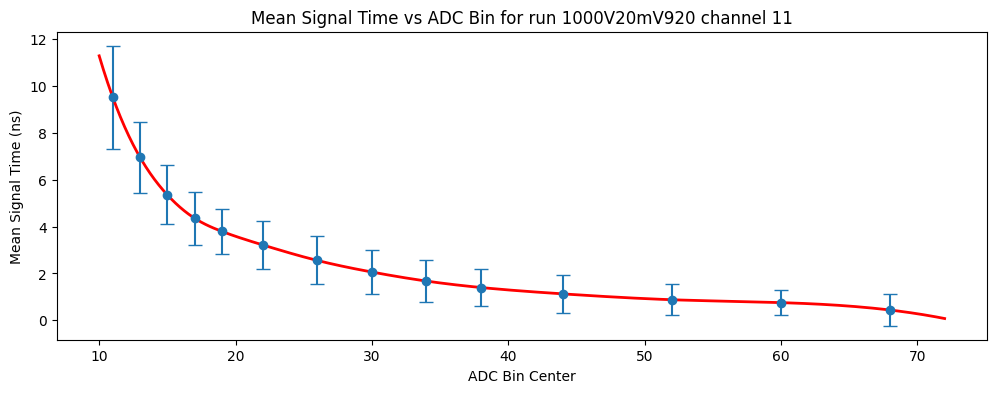

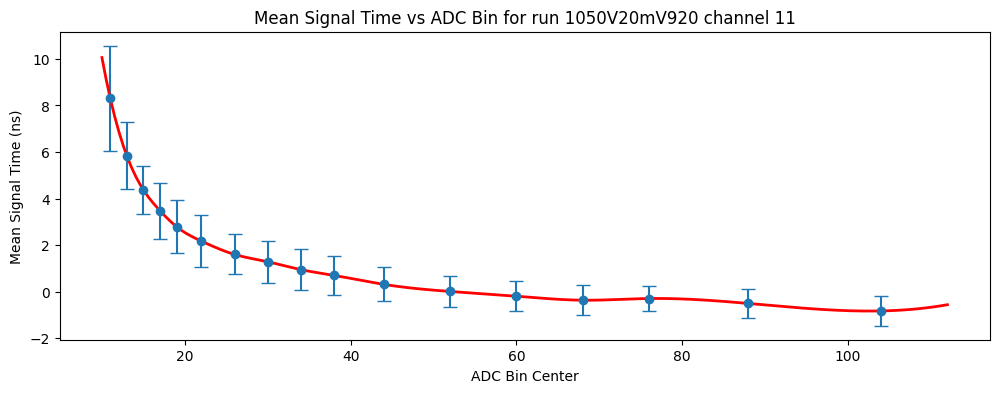

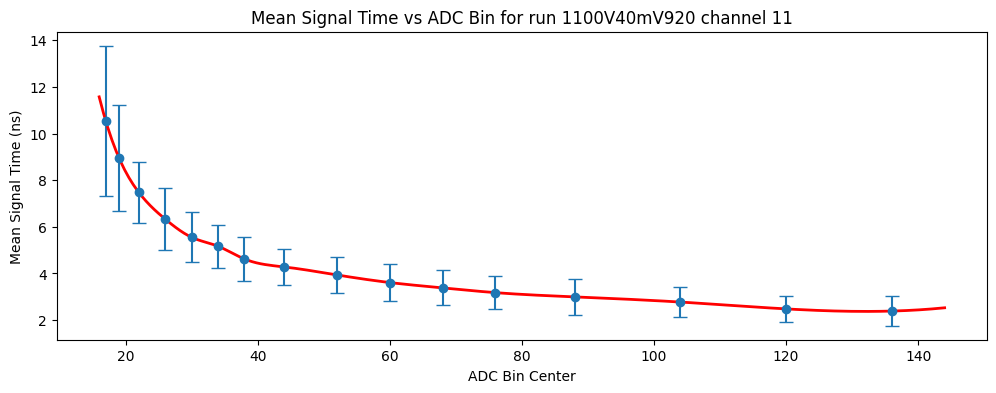

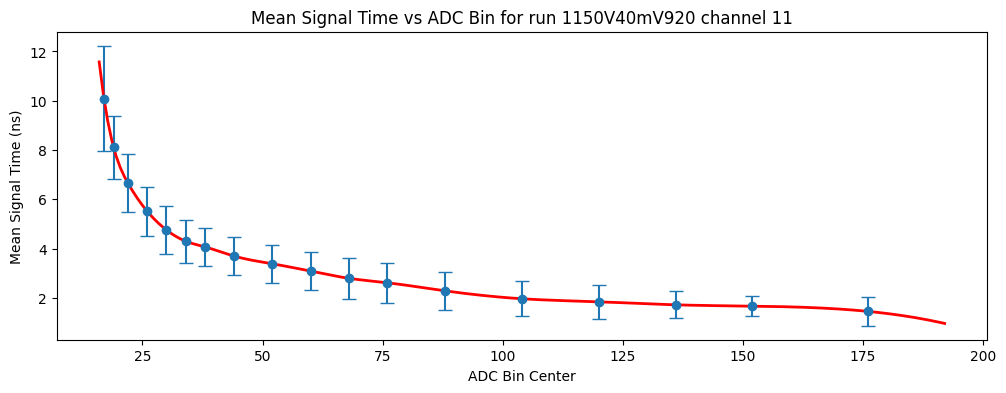

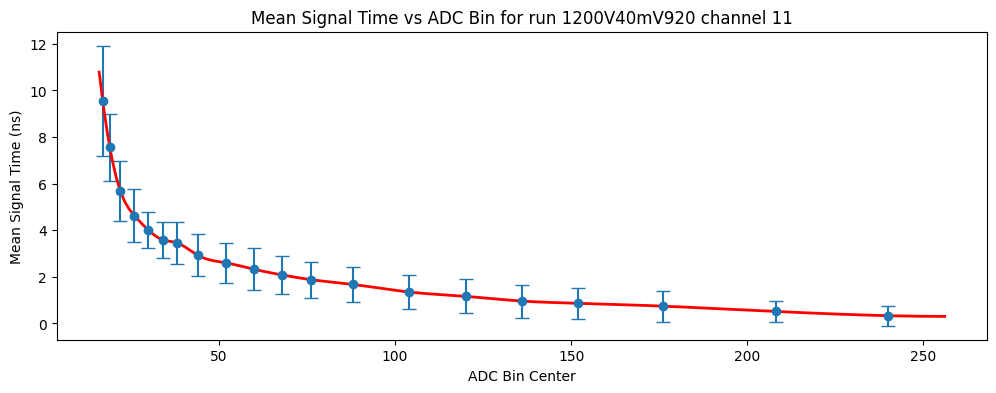

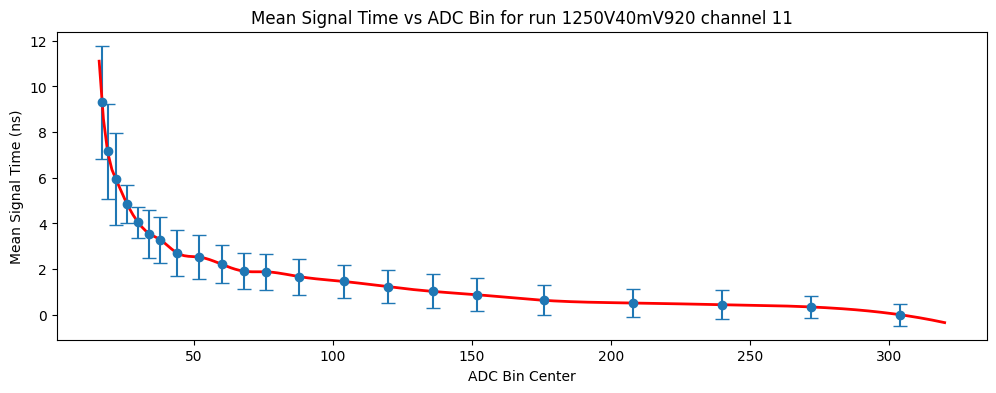

In [22]:
# Plot the mean signal time as a function of ADC bin, and show the standard deviation as error bars

for run_name in time_walk_correction_funcs.keys():

    time_walk_correction_func = time_walk_correction_funcs[run_name]
    fit_range = time_walk_correction_ranges[run_name]
    mean_signal_times_sel = time_walk_correction_means_sel[run_name]
    std_signal_times_sel = time_walk_correction_stds_sel[run_name]
    adc_bin_centers_sel = time_walk_correction_bin_centers_sel[run_name]

    plt.figure(figsize=(12, 4))
    plt.errorbar(adc_bin_centers_sel, mean_signal_times_sel, yerr=std_signal_times_sel, fmt='o', capsize=5)
    x_fit = np.linspace(fit_range[0], fit_range[1], 200)
    y_fit = time_walk_correction_func(x_fit)
    plt.plot(x_fit, y_fit, color='red', linestyle='-', lw=2, label='Interpolation Function')

    plt.xlabel('ADC Bin Center')
    plt.ylabel('Mean Signal Time (ns)')
    plt.title(f'Mean Signal Time vs ADC Bin for run {run_name} channel {channel}')
    plt.savefig(f'I:/fd2_analyses/mean_signal_time_vs_adc_bin_run{run_name}_chan{channel:02d}.png')
    plt.show()

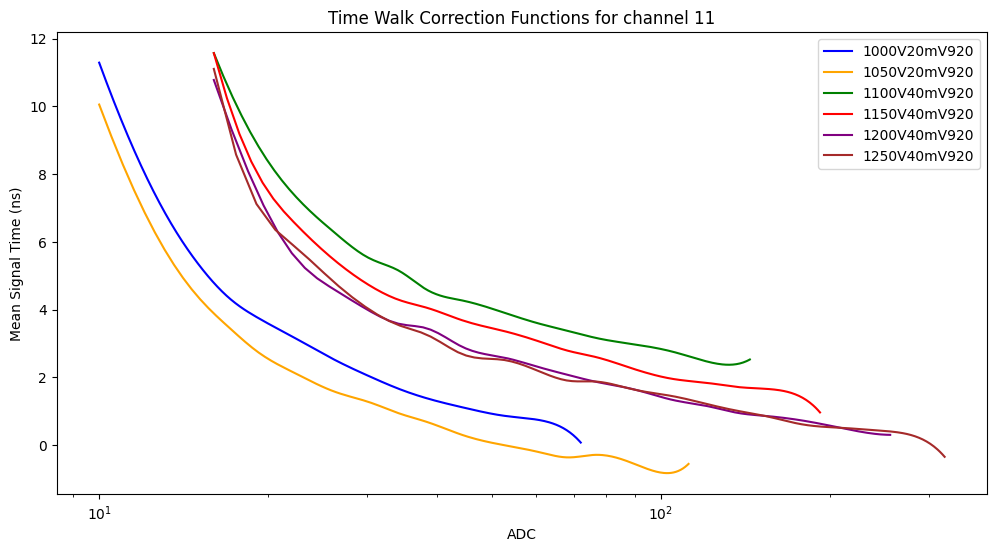

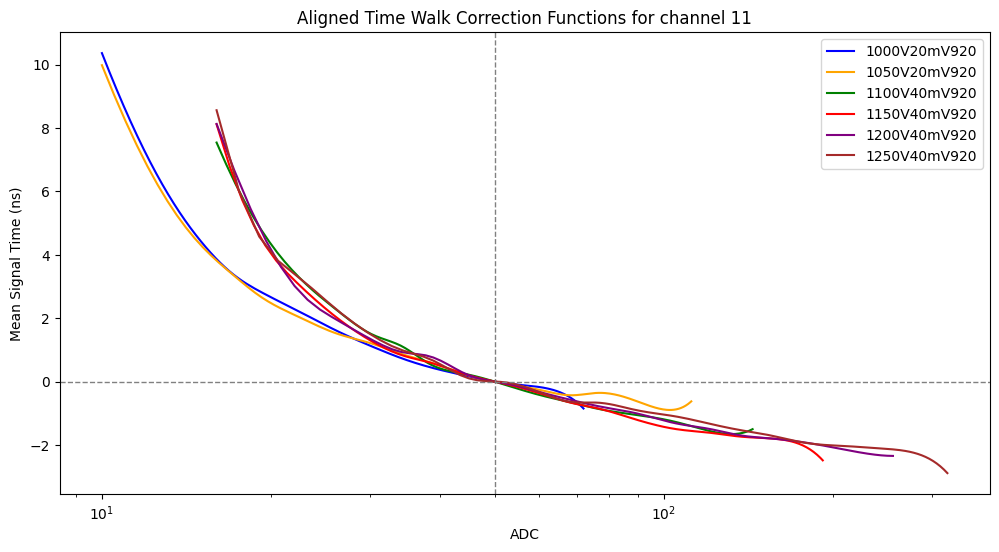

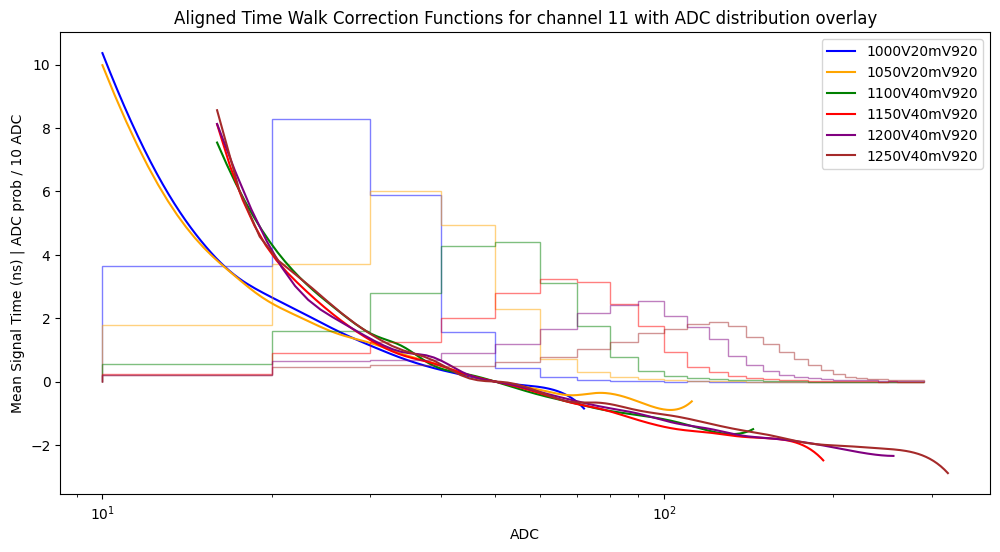

In [42]:
# Overlay the correction functions, use log x axis to better see the low ADC region

# find correction factors to align all at t=0 at ADC = 50
offsets = {}
for run_name in time_walk_correction_funcs.keys():
    time_walk_correction_func = time_walk_correction_funcs[run_name]
    fit_range = time_walk_correction_ranges[run_name]
    offset = time_walk_correction_func(50)
    offsets[run_name] = offset

# define six distinct colors for the different HV settings:
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown']

for i in range(3):  # with and without offset applied and with adc distributions overlayed
    plt.figure(figsize=(12, 6))
    for ic,run_name in enumerate(time_walk_correction_funcs.keys()):
        time_walk_correction_func = time_walk_correction_funcs[run_name]
        fit_range = time_walk_correction_ranges[run_name]

        x_fit = np.linspace(fit_range[0], fit_range[1], 200)
        y_fit = time_walk_correction_func(x_fit)
        if i>0:
            y_fit = time_walk_correction_func(x_fit) - offsets[run_name]
        plt.plot(x_fit, y_fit, label=f'{run_name}',color=colors[ic])

        if i==2: # overlay the adc distribution
            data = get_data(run_name=run_name, channel=channel)
            mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))
            mask_adc = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5) & (data['adcs']<400))
            counts,bins = np.histogram(data['adcs'][mask_led]-adc_offset,bins=np.arange(10,300,10))
            total_counts = np.sum(counts)
            scaled_counts = 20*counts/total_counts

            plt.hist(bins[:-1], bins, weights=scaled_counts, histtype='step', color=colors[ic], alpha=0.5)

        plt.xlabel('ADC')
        plt.ylabel('Mean Signal Time (ns)')
        plt.xscale('log')

    plt.legend()
    if i==0:
        plt.title(f'Time Walk Correction Functions for channel {channel}')
        plt.savefig(f'I:/fd2_analyses/time_walk_correction_functions_chan{channel:02d}.png')
    elif i==1:
        # add horizontal line at 0 and vertical line at 50:
        plt.axhline(0, color='gray', linestyle='--', linewidth=1)
        plt.axvline(50, color='gray', linestyle='--', linewidth=1)
        plt.title(f'Aligned Time Walk Correction Functions for channel {channel}')
        plt.savefig(f'I:/fd2_analyses/time_walk_correction_functions_chan{channel:02d}_aligned.png')
    else:
        # overlay the adc distributions for the different
        plt.ylabel('Mean Signal Time (ns) | ADC prob / 10 ADC')
        plt.title(f'Aligned Time Walk Correction Functions for channel {channel} with ADC distribution overlay')
        plt.savefig(f'I:/fd2_analyses/time_walk_correction_functions_chan{channel:02d}_aligned_overlay.png')
    plt.show()



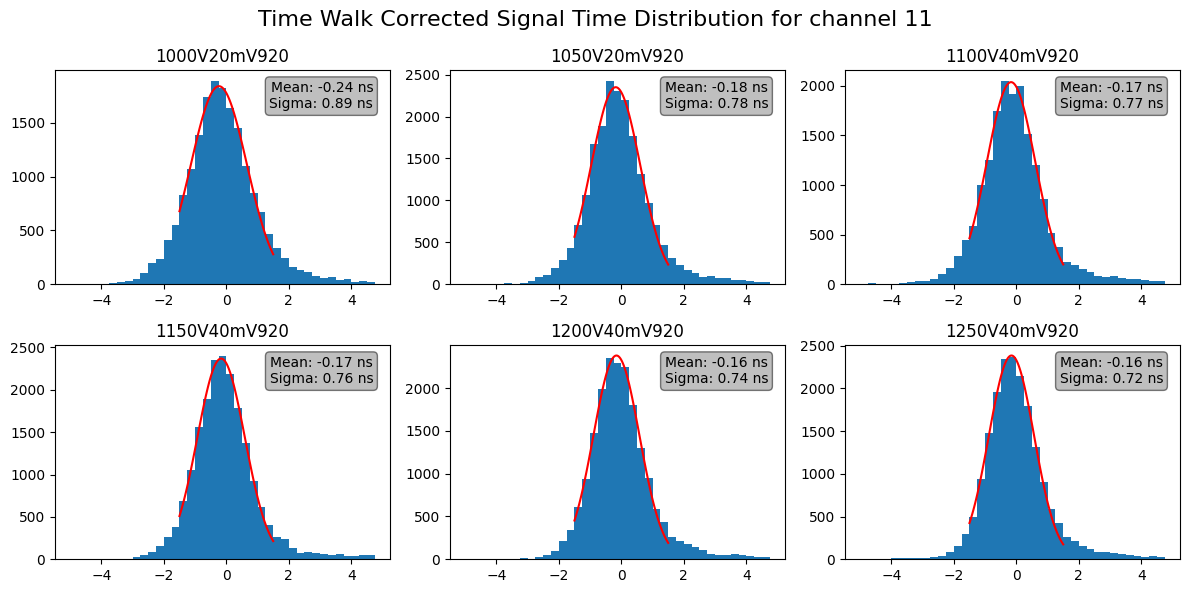

In [24]:
# Apply the time walk correction to the signal times, and show the distribution of signal times, use 2 rows and 3 columns

mean_cst = {}
std_cst = {}

fig, ax = plt.subplots(2,3, figsize=(12, 6))
for i,run_name in enumerate(time_walk_correction_funcs.keys()):
    axis = ax[i//3,  i%3]
    time_walk_correction_func = time_walk_correction_funcs[run_name]
    data = get_data(run_name=run_name, channel=channel)

    mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))

    corrected_signal_times = []
    for signal_time,adc in zip(data['signal_times'][mask_led],data['adcs'][mask_led]):
        time_walk = time_walk_correction_func(adc-adc_offset)
        corrected_signal_times.append(signal_time - time_walk)

    axis.hist(corrected_signal_times,bins=np.arange(-5.,5.,0.25))
    axis.set_title(f'{run_name}')

    # fit the range from -1.5 to 1.5 to a Gaussian

    hist, bin_edges = np.histogram(corrected_signal_times, bins=np.arange(-1.5,1.5,0.25))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    # Initial guess for fit parameters: amplitude, mean, stddev
    p0 = [np.max(hist), np.mean(corrected_signal_times), np.std(corrected_signal_times)]

    popt, pcov = curve_fit(lambda x, A, mu, sigma: A * np.exp(-(x - mu)**2 / (2 * sigma**2)), bin_centers, hist, p0=p0)
    mean_cst[run_name] = popt[1]
    std_cst[run_name] = abs(popt[2])
    # Plot the fit
    x_fit = np.linspace(-1.5, 1.5, 100)
    y_fit = popt[0] * np.exp(-(x_fit - popt[1])**2 / (2 * popt[2]**2))
    axis.plot(x_fit, y_fit, color='red', linestyle='-')
    # Add a text box with mean and sigma values shown
    textstr = '\n'.join((
        f'Mean: {popt[1]:.2f} ns',
        f'Sigma: {abs(popt[2]):.2f} ns'))
    props = dict(boxstyle='round', facecolor='grey', alpha=0.5)
    axis.text(0.95, 0.95, textstr, transform=axis.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=props)


plt.suptitle(f'Time Walk Corrected Signal Time Distribution for channel {channel}', fontsize=16)
plt.tight_layout()
plt.savefig(f'I:/fd2_analyses/corr_signal_time_distribution_chan{channel:02d}.png')
plt.show()


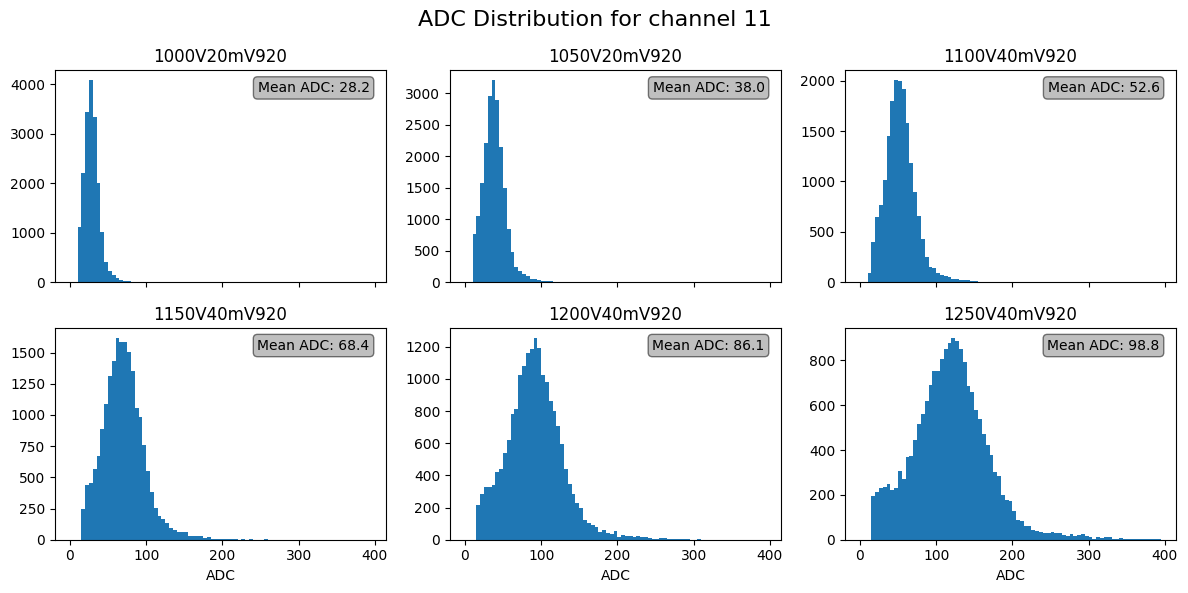

In [25]:
# Find the mean of the ADC distributions for the same runs to define the gains for each HV setting. Then plot the corrected signal time resolution (sigma from fit) as a function of gain.

mean_adcs = {}

fig, ax = plt.subplots(2,3, figsize=(12, 6), sharex=True)
for i,run_name in enumerate(time_walk_correction_funcs.keys()):
    axis = ax[i//3,  i%3]
    data = get_data(run_name=run_name, channel=channel)

    mask_led = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5))
    mask_adc = ((data['pmt_time_modulus_zeroeds'] > -5) & (data['pmt_time_modulus_zeroeds'] < 5) & (data['adcs']<400))
    axis.hist(data['adcs'][mask_led]-adc_offset,bins=np.arange(0,400,5))
    axis.set_title(f'{run_name}')
    if i>2:
        axis.set_xlabel('ADC')

    mean_adc = np.mean(data['adcs'][mask_adc]) - adc_offset
    mean_adcs[run_name] = mean_adc

    # Add a text box with mean shown
    textstr = f'Mean ADC: {mean_adc:.1f}'
    props = dict(boxstyle='round', facecolor='grey', alpha=0.5)
    axis.text(0.95, 0.95, textstr, transform=axis.transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right', bbox=props)



plt.suptitle(f'ADC Distribution for channel {channel}', fontsize=16)
plt.tight_layout()
plt.savefig(f'I:/fd2_analyses/adc_distribution_chan{channel:02d}_led920.png')
plt.show()



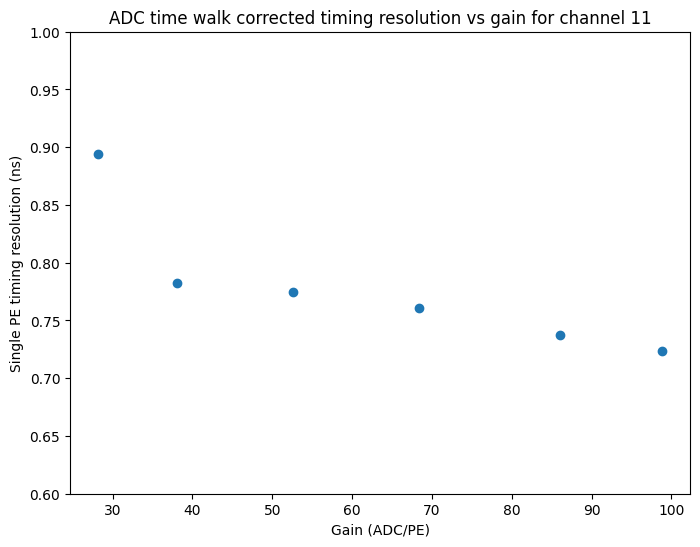

In [26]:
# Finally show the corrected signal time resolution as a function of mean ADC (gain proxy)

plt.figure(figsize=(8, 6))

gains = []
time_resols = []
for run_name in time_walk_correction_funcs.keys():
    gains.append(mean_adcs[run_name])
    time_resols.append(std_cst[run_name])

plt.plot(gains, time_resols, marker='o', linestyle=' ')
plt.xlabel('Gain (ADC/PE)')
plt.ylabel('Single PE timing resolution (ns)')
plt.title(f'ADC time walk corrected timing resolution vs gain for channel {channel}')
plt.ylim(0.6,1.)
plt.savefig(f'I:/fd2_analyses/adc_timing_resolution_chan{channel:02d}.png')
plt.show()
